In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, accuracy_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.figsize': (10, 5)})

ARQUIVO = 'nij-challenge2021_full_dataset.csv'
LABEL = 'Recidivism_Within_3years'
SEED = 42

In [2]:
df_raw = pd.read_csv(ARQUIVO)

print("=== VISÃO GERAL DOS DADOS BRUTOS ===")
print(f"Dimensões : {df_raw.shape[0]:,} registros × {df_raw.shape[1]} colunas")
print(f"\nPrimeiras linhas:")
df_raw.head(3)

=== VISÃO GERAL DOS DADOS BRUTOS ===
Dimensões : 25,835 registros × 54 colunas

Primeiras linhas:


,ID,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,...,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years,Recidivism_Arrest_Year1,Recidivism_Arrest_Year2,Recidivism_Arrest_Year3,Training_Sample
0,1,M,BLACK,43-47,16,No,3.0,Standard,At least some college,3 or more,...,0.000000,0.0,0.488562,0.44761,No,No,No,No,No,1
1,2,M,BLACK,33-37,16,No,6.0,Specialized,Less than HS diploma,1,...,0.000000,0.0,0.425234,2.00000,No,Yes,No,No,Yes,1
2,3,M,BLACK,48 or older,24,No,7.0,High,At least some college,3 or more,...,0.166667,0.0,0.000000,0.00000,No,Yes,No,Yes,No,1


=== TIPOS DE DADOS ===
ID                                    int64
Gender                               object
Race                                 object
Age_at_Release                       object
Residence_PUMA                        int64
Gang_Affiliated                      object
Supervision_Risk_Score_First        float64
Supervision_Level_First              object
Education_Level                      object
Dependents                           object
Prison_Offense                       object
Prison_Years                         object
Prior_Arrest_Episodes_Felony         object
Prior_Arrest_Episodes_Misd           object
Prior_Arrest_Episodes_Violent        object
Prior_Arrest_Episodes_Property       object
Prior_Arrest_Episodes_Drug           object
_v1                                  object
Prior_Arrest_Episodes_DVCharges      object
Prior_Arrest_Episodes_GunCharges     object
Prior_Conviction_Episodes_Felony     object
Prior_Conviction_Episodes_Misd       object
Prior_Con

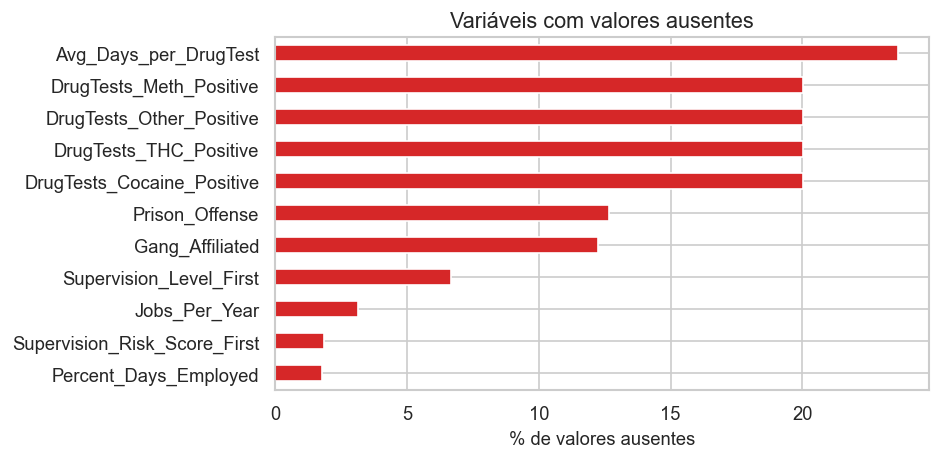

In [3]:
print("=== TIPOS DE DADOS ===")
print(df_raw.dtypes.to_string())

print("\n=== VALORES AUSENTES ===")
miss = df_raw.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df_raw) * 100).round(2)
df_miss = pd.DataFrame({'Ausentes': miss, '% do total': miss_pct})
print(df_miss.to_string())

# Gráfico de valores ausentes
fig, ax = plt.subplots(figsize=(8, 4))
miss_pct.sort_values().plot(kind='barh', ax=ax, color='#d62728')
ax.set_xlabel('% de valores ausentes')
ax.set_title('Variáveis com valores ausentes')
plt.tight_layout()
plt.show()

# Transformação dos dados

In [ ]:
# --- Colunas a remover ---
REMOVER = [
    'ID',                       # identificador sem valor preditivo
    'Training_Sample',          # indicador de partição
    'Recidivism_Arrest_Year1',  # DATA LEAKAGE
    'Recidivism_Arrest_Year2',  # DATA LEAKAGE
    'Recidivism_Arrest_Year3',  # DATA LEAKAGE
    '_v1', '_v2', '_v3', '_v4', # colunas auxiliares sem semântica
    'Residence_PUMA',           # código geográfico arbitrário -> deixar mas tratar como categorico
]

df = df_raw.drop(columns=REMOVER).copy()

# --- Converter label Yes/No → 1/0 ---
df[LABEL] = df[LABEL].map({'Yes': 1, 'No': 0}).astype(int)

# --- Mapeamento das variáveis ordinais (censored "X or more" -> inteiro) ---
MAPA_ORDINAIS = {
    'Prior_Arrest_Episodes_Felony':    {'0':0,'1':1,'2':2,'3':3,'4':4,'5':5,
                                        '6':6,'7':7,'8':8,'9':9,'10 or more':10},
    'Prior_Arrest_Episodes_Misd':      {'0':0,'1':1,'2':2,'3':3,'4':4,'5':5,
                                        '6 or more':6},
    'Prior_Arrest_Episodes_Violent':   {'0':0,'1':1,'2':2,'3 or more':3},
    'Prior_Arrest_Episodes_Property':  {'0':0,'1':1,'2':2,'3':3,'4':4,
                                        '5 or more':5},
    'Prior_Arrest_Episodes_Drug':      {'0':0,'1':1,'2':2,'3':3,'4':4,
                                        '5 or more':5},
    'Prior_Conviction_Episodes_Felony':{'0':0,'1':1,'2':2,'3 or more':3},
    'Prior_Conviction_Episodes_Misd':  {'0':0,'1':1,'2':2,'3':3,'4 or more':4},
    'Prior_Conviction_Episodes_Prop':  {'0':0,'1':1,'2':2,'3 or more':3},
    'Prior_Conviction_Episodes_Drug':  {'0':0,'1':1,'2 or more':2},
    'Delinquency_Reports':             {'0':0,'1':1,'2':2,'3':3,'4 or more':4},
    'Program_Attendances':             {'0':0,'1':1,'2':2,'3':3,'4':4,'5':5,
                                        '6':6,'7':7,'8':8,'9':9,'10 or more':10},
    'Program_UnexcusedAbsences':       {'0':0,'1':1,'2':2,'3 or more':3},
    'Residence_Changes':               {'0':0,'1':1,'2':2,'3 or more':3},
    'Dependents':                      {'0':0,'1':1,'2':2,'3 or more':3},
}

for col, mapa in MAPA_ORDINAIS.items():
    df[col] = df[col].map(mapa)

# --- Binárias Yes/No -> 1/0 ---
BINARIAS_YESNO = [
    'Gang_Affiliated', 'Prior_Arrest_Episodes_DVCharges',
    'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Viol',
    'Prior_Revocations_Parole', 'Prior_Revocations_Probation',
    'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other',
    'Violations_ElectronicMonitoring', 'Violations_Instruction',
    'Violations_FailToReport', 'Violations_MoveWithoutPermission',
    'Employment_Exempt',
]
for col in BINARIAS_YESNO:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# --- Nominais: Label Encoding para uso na árvore ---
# (árvore de decisão do sklearn exige valores numéricos)
NOMINAIS = ['Gender', 'Race', 'Age_at_Release', 'Supervision_Level_First',
            'Education_Level', 'Prison_Offense', 'Prison_Years']
le_dict = {}
for col in NOMINAIS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# --- Tratar valores ausentes ---
# Estratégia: mediana para numéricas/ordinais, moda para binárias/nominais
for col in df.columns:
    if col == LABEL:
        continue
    if df[col].isnull().sum() == 0:
        continue
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"\nDataset após limpeza: {df.shape[0]:,} registros x {df.shape[1]} colunas")
print(f"Valores ausentes restantes: {df.isnull().sum().sum()}")

Gender: {'F': np.int64(0), 'M': np.int64(1)}
Race: {'BLACK': np.int64(0), 'WHITE': np.int64(1)}
Age_at_Release: {'18-22': np.int64(0), '23-27': np.int64(1), '28-32': np.int64(2), '33-37': np.int64(3), '38-42': np.int64(4), '43-47': np.int64(5), '48 or older': np.int64(6)}
Supervision_Level_First: {'High': np.int64(0), 'Specialized': np.int64(1), 'Standard': np.int64(2), 'nan': np.int64(3)}
Education_Level: {'At least some college': np.int64(0), 'High School Diploma': np.int64(1), 'Less than HS diploma': np.int64(2)}
Prison_Offense: {'Drug': np.int64(0), 'Other': np.int64(1), 'Property': np.int64(2), 'Violent/Non-Sex': np.int64(3), 'Violent/Sex': np.int64(4), 'nan': np.int64(5)}
Prison_Years: {'1-2 years': np.int64(0), 'Greater than 2 to 3 years': np.int64(1), 'Less than 1 year': np.int64(2), 'More than 3 years': np.int64(3)}

Dataset após limpeza: 25,835 registros x 44 colunas
Valores ausentes restantes: 0


# Análise da variável resposta

=== VARIÁVEL RESPOSTA ===
                              N     %
Recidivism_Within_3years             
1                         14904  57.7
0                         10931  42.3


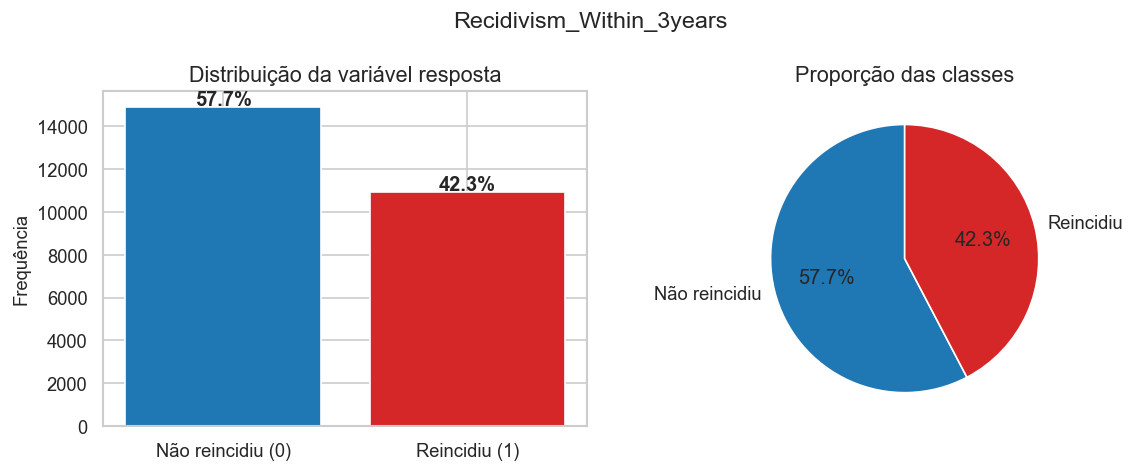

In [5]:
print("=== VARIÁVEL RESPOSTA ===")
vc = df[LABEL].value_counts()
pct = df[LABEL].value_counts(normalize=True) * 100
print(pd.DataFrame({'N': vc, '%': pct.round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfico de barras
axes[0].bar(['Não reincidiu (0)', 'Reincidiu (1)'],
            vc.values, color=['#1f77b4', '#d62728'], edgecolor='white')
for i, (n, p) in enumerate(zip(vc.values, pct.values)):
    axes[0].text(i, n + 100, f'{p:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Distribuição da variável resposta')
axes[0].set_ylabel('Frequência')

# Pizza
axes[1].pie(vc.values, labels=['Não reincidiu', 'Reincidiu'],
            autopct='%1.1f%%', colors=['#1f77b4', '#d62728'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporção das classes')

plt.suptitle('Recidivism_Within_3years', fontsize=14)
plt.tight_layout()
plt.show()

# Análise univariada

=== ESTATÍSTICAS DESCRITIVAS — VARIÁVEIS CONTÍNUAS ===
       Supervision_Risk_Score_First  Avg_Days_per_DrugTest  DrugTests_THC_Positive  DrugTests_Cocaine_Positive  DrugTests_Meth_Positive  DrugTests_Other_Positive  Percent_Days_Employed  Jobs_Per_Year
count                     25835.000              25835.000               25835.000                   25835.000                25835.000                 25835.000              25835.000      25835.000
mean                          6.081                 84.803                   0.051                       0.011                    0.010                     0.006                  0.482          0.765
std                           2.359                103.694                   0.126                       0.055                    0.054                     0.037                  0.421          0.801
min                           1.000                  0.500                   0.000                       0.000                    0.000          

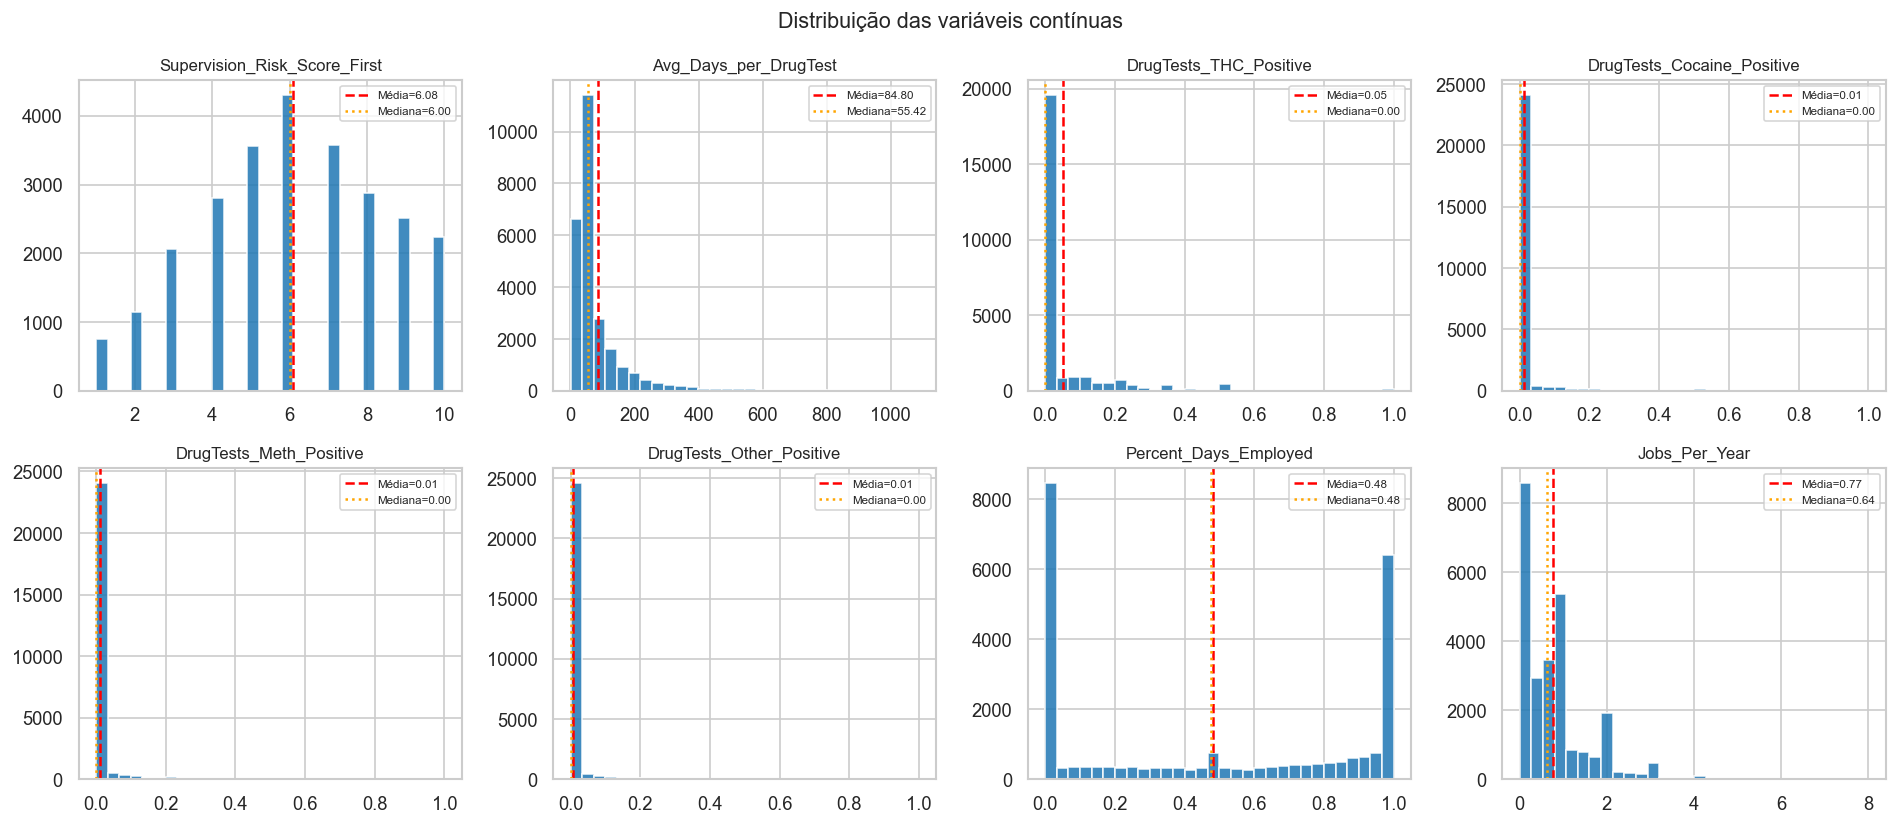

In [6]:

CONTINUAS = ['Supervision_Risk_Score_First', 'Avg_Days_per_DrugTest',
             'DrugTests_THC_Positive', 'DrugTests_Cocaine_Positive',
             'DrugTests_Meth_Positive', 'DrugTests_Other_Positive',
             'Percent_Days_Employed', 'Jobs_Per_Year']

print("=== ESTATÍSTICAS DESCRITIVAS — VARIÁVEIS CONTÍNUAS ===")
print(df[CONTINUAS].describe().round(3).to_string())

n_cols = 4
n_rows = int(np.ceil(len(CONTINUAS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flat

for ax, col in zip(axes, CONTINUAS):
    ax.hist(df[col], bins=30, color='#1f77b4', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5,
               label=f'Média={df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='orange', linestyle=':',  linewidth=1.5,
               label=f'Mediana={df[col].median():.2f}')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

for ax in list(axes)[len(CONTINUAS):]:
    ax.set_visible(False)

plt.suptitle('Distribuição das variáveis contínuas', fontsize=13)
plt.tight_layout()
plt.show()

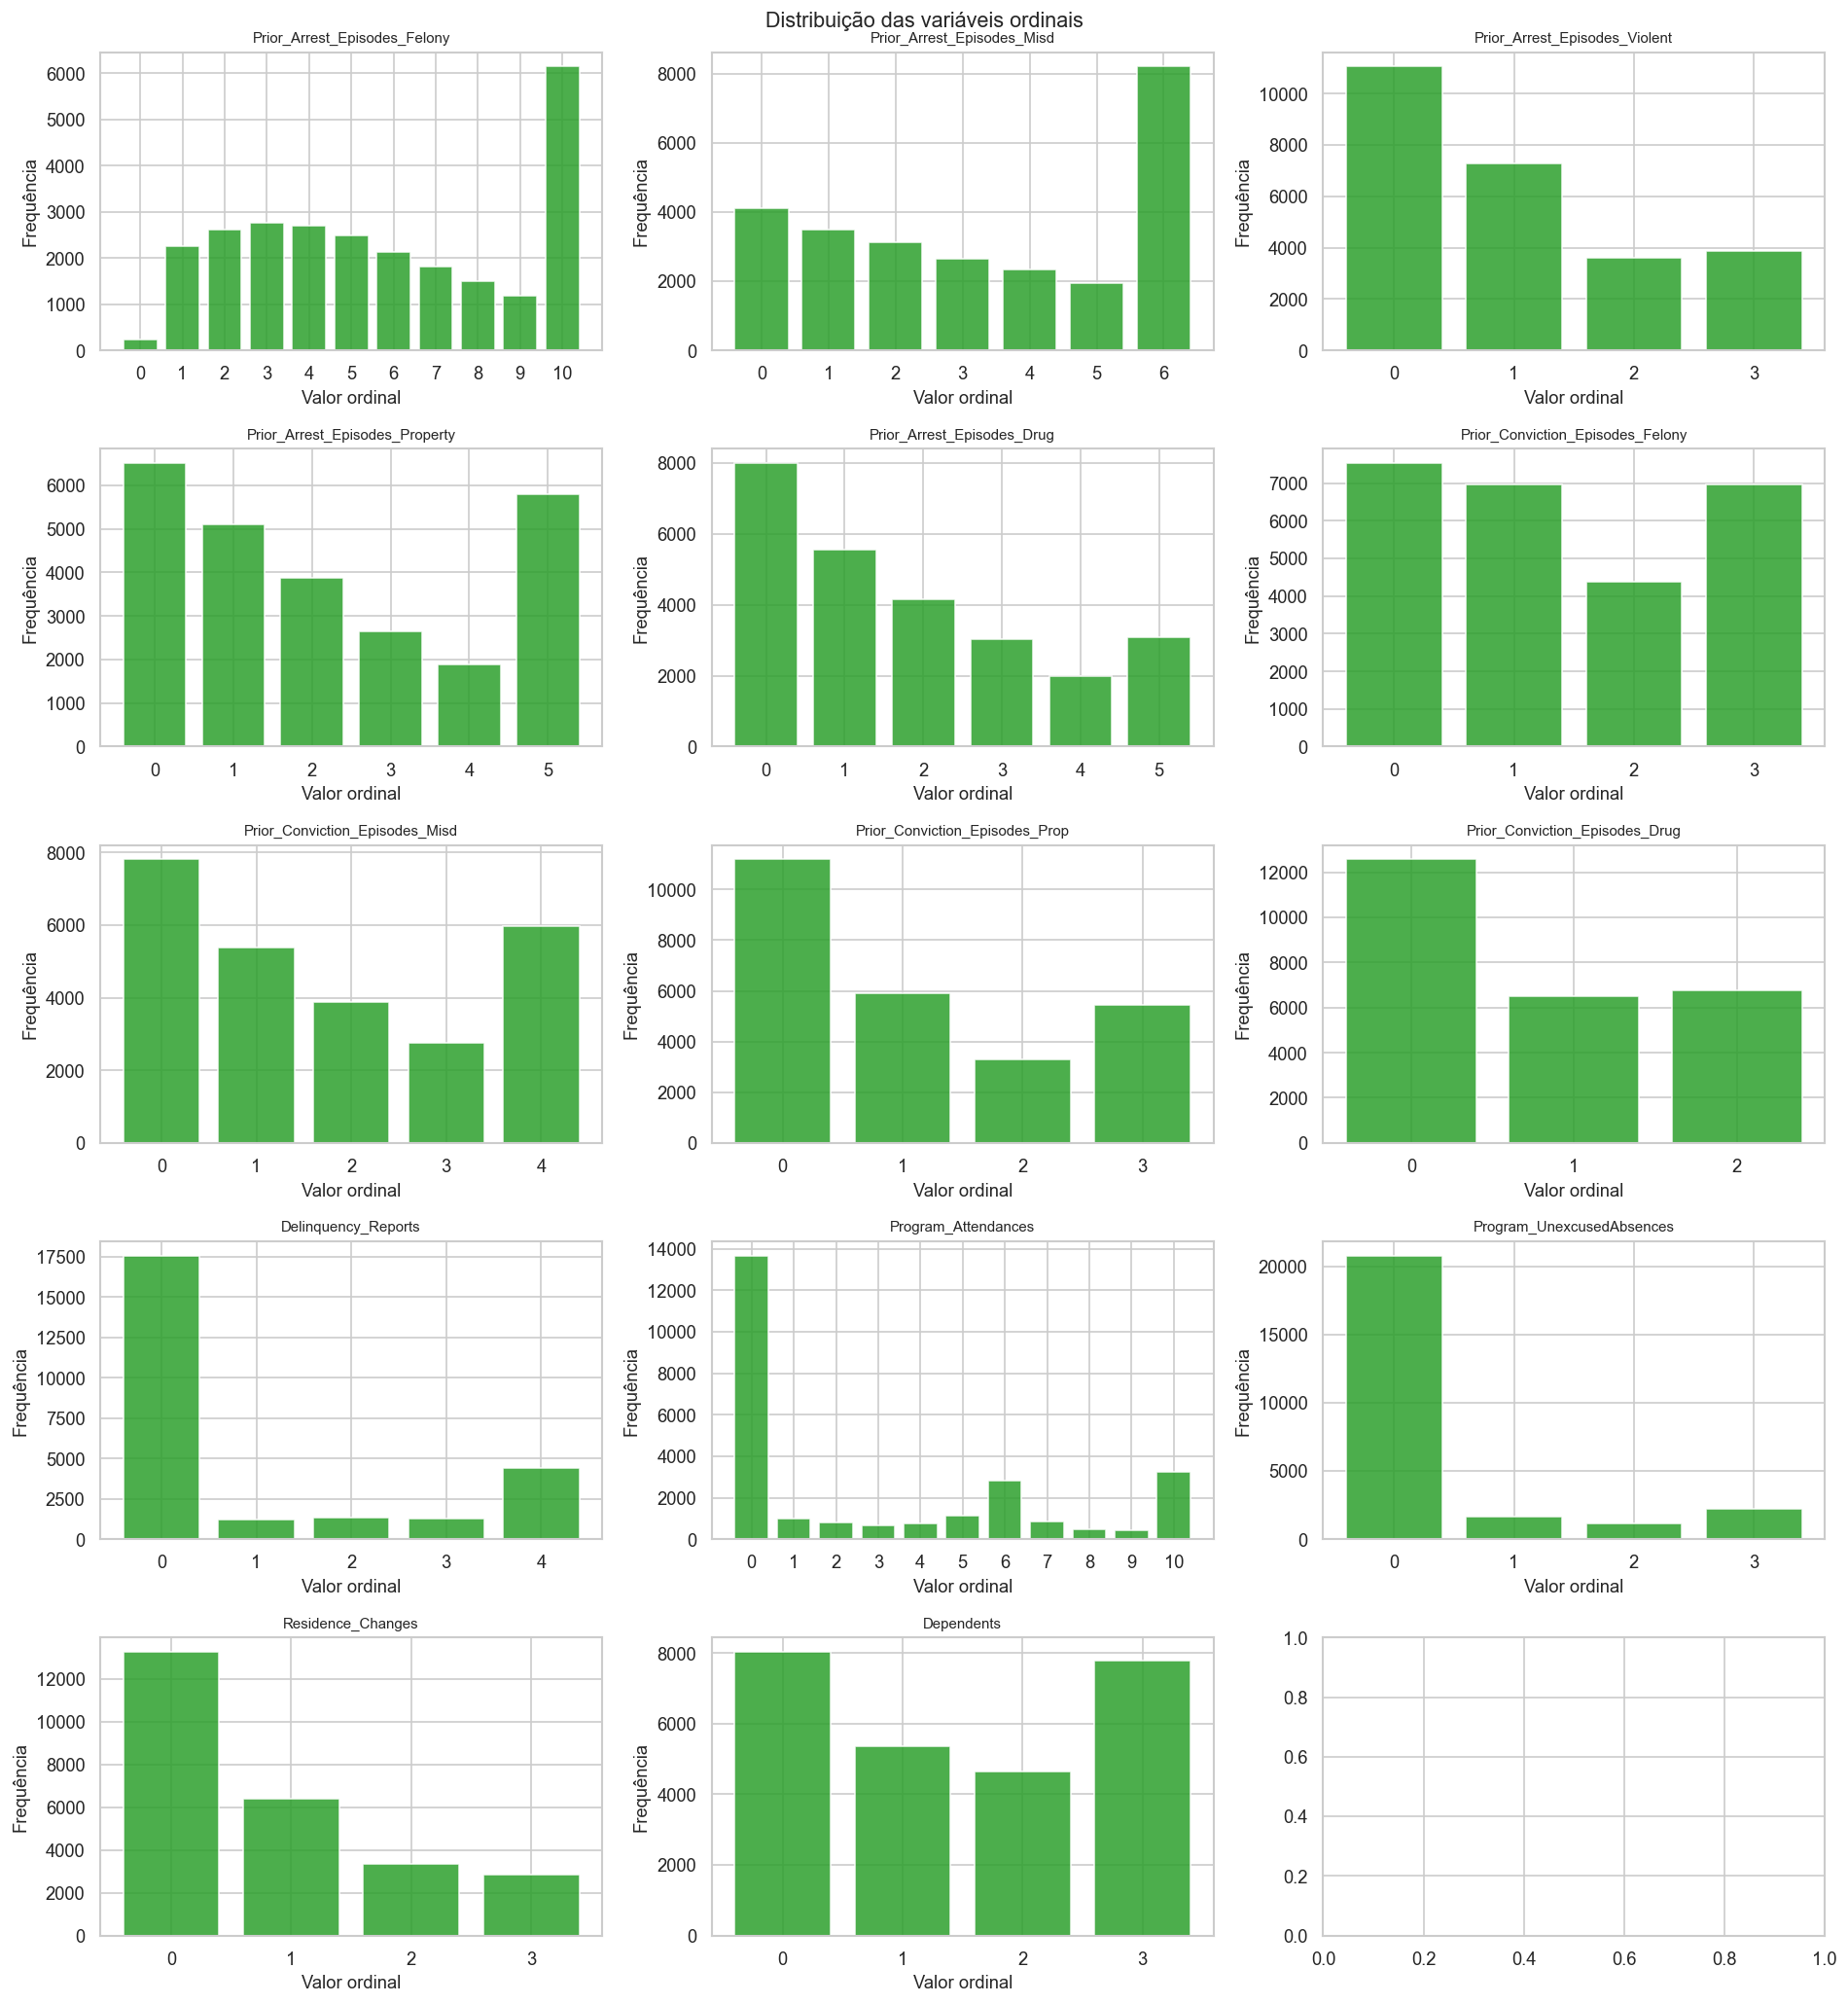

In [7]:
ORDINAIS = list(MAPA_ORDINAIS.keys())

n_cols = 3
n_rows = int(np.ceil(len(ORDINAIS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flat

for ax, col in zip(axes, ORDINAIS):
    vc_col = df[col].value_counts().sort_index()
    ax.bar(vc_col.index.astype(str), vc_col.values,
           color='#2ca02c', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Valor ordinal')
    ax.set_ylabel('Frequência')

for ax in list(axes)[len(ORDINAIS):]:
    ax.set_visible(False)

plt.suptitle('Distribuição das variáveis ordinais', fontsize=13)
plt.tight_layout()
plt.show()


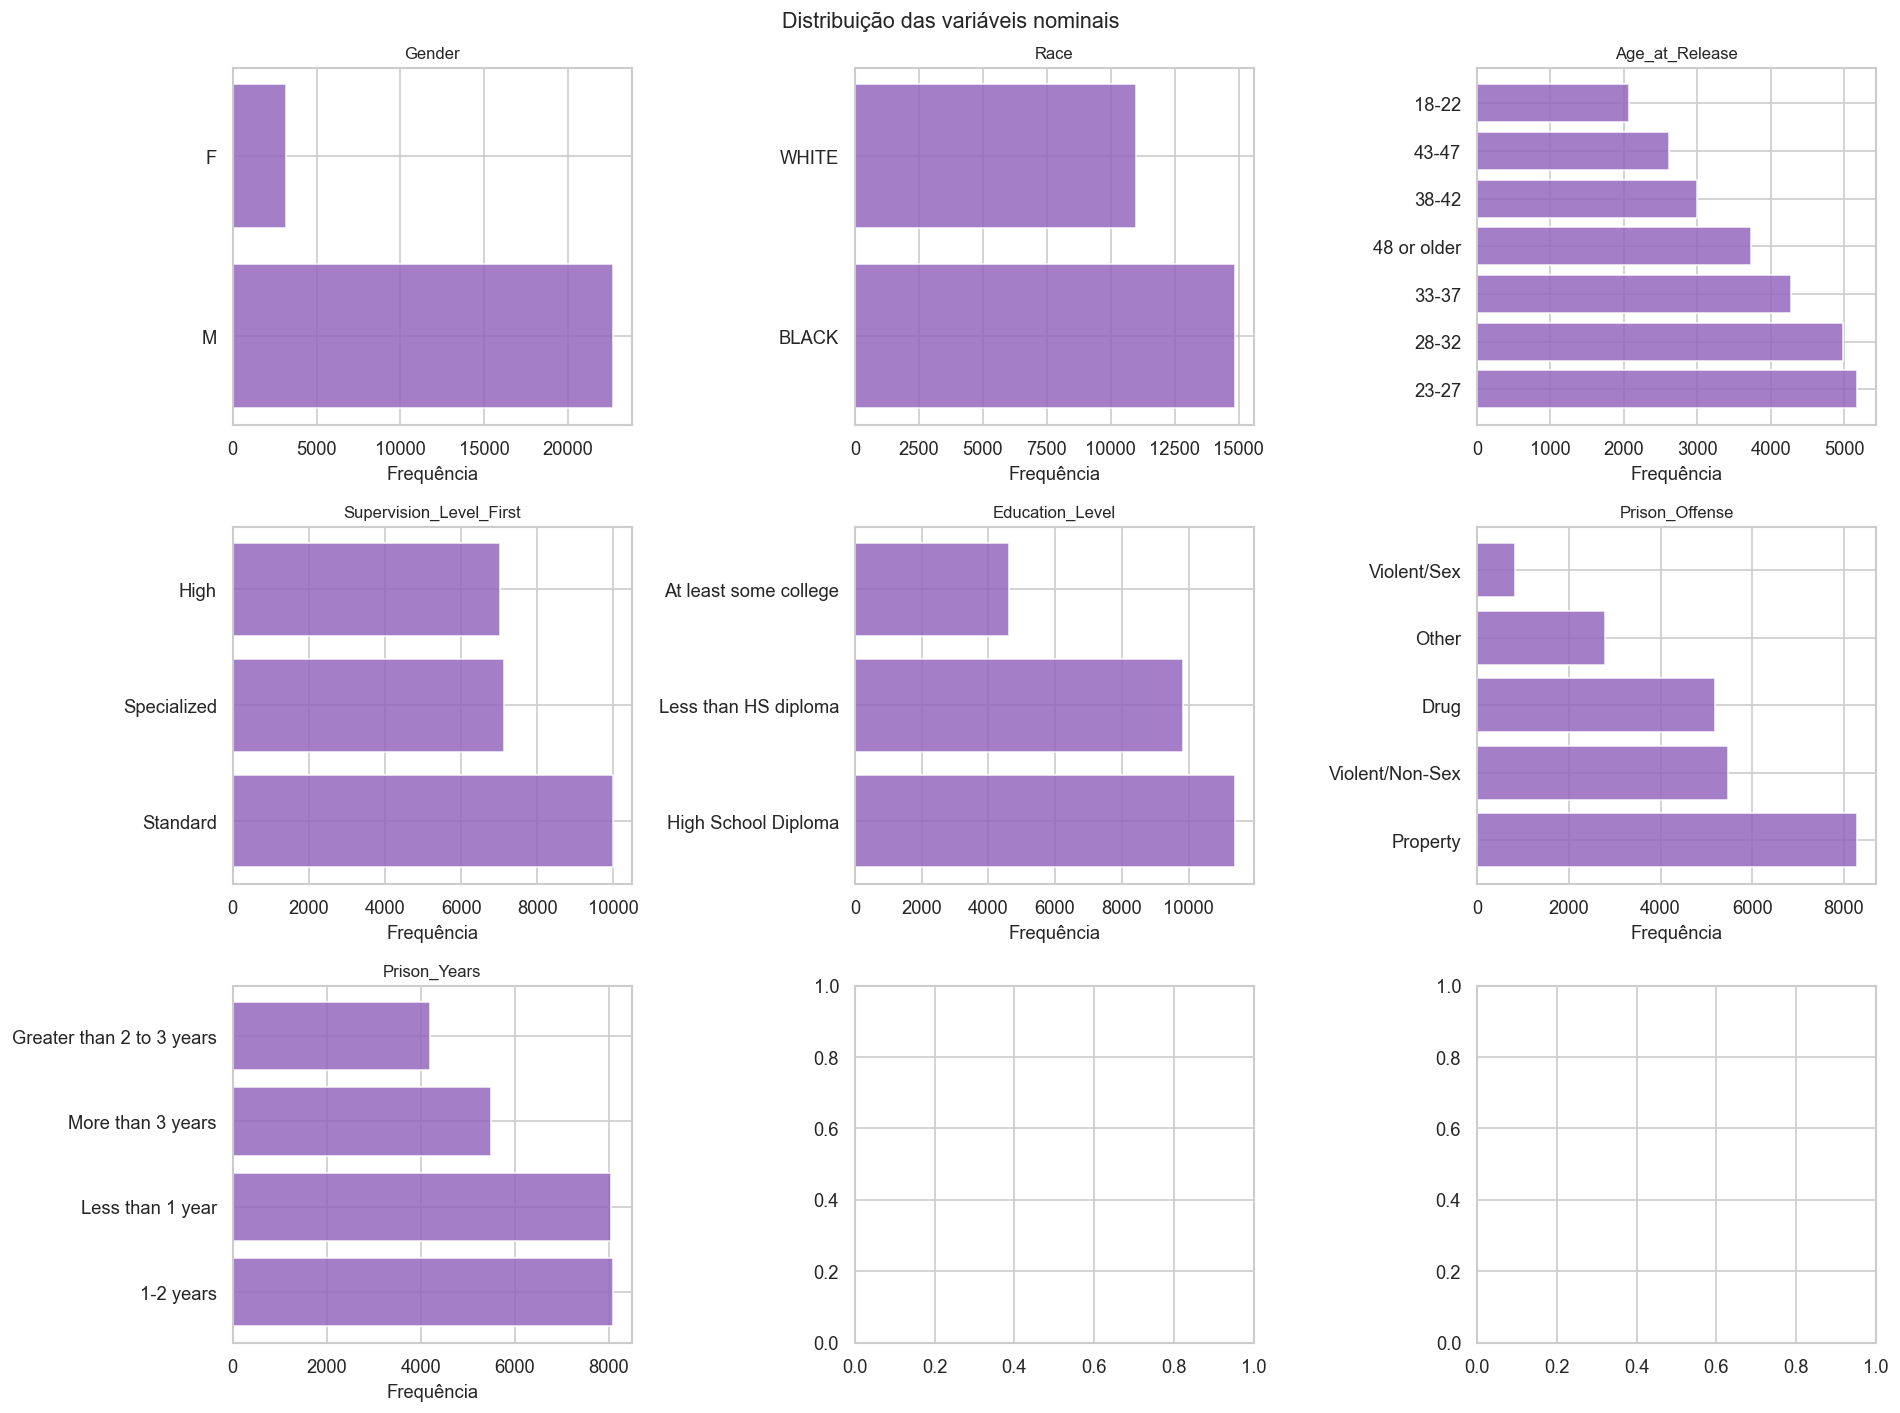

In [8]:

# Reconstruir categorias originais para melhor visualização
df_viz = df_raw.drop(columns=REMOVER).copy()
df_viz[LABEL] = df_viz[LABEL].map({'Yes': 'Reincidiu', 'No': 'Não reincidiu'})

NOMINAIS_ORIG = ['Gender', 'Race', 'Age_at_Release', 'Supervision_Level_First',
                 'Education_Level', 'Prison_Offense', 'Prison_Years']

n_cols = 3
n_rows = int(np.ceil(len(NOMINAIS_ORIG) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flat

for ax, col in zip(axes, NOMINAIS_ORIG):
    vc_col = df_viz[col].value_counts()
    ax.barh(vc_col.index.astype(str), vc_col.values,
            color='#9467bd', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Frequência')

for ax in list(axes)[len(NOMINAIS_ORIG):]:
    ax.set_visible(False)

plt.suptitle('Distribuição das variáveis nominais', fontsize=13)
plt.tight_layout()
plt.show()

# Análise bivariada

=== ANÁLISE BIVARIADA: CONTÍNUAS vs. LABEL ===
Recidivism_Within_3years      Mediana — Não reincidiu  Mediana — Reincidiu
Supervision_Risk_Score_First                    6.000                6.000
Avg_Days_per_DrugTest                          55.425               55.425
DrugTests_THC_Positive                          0.000                0.000
DrugTests_Cocaine_Positive                      0.000                0.000
DrugTests_Meth_Positive                         0.000                0.000
DrugTests_Other_Positive                        0.000                0.000
Percent_Days_Employed                           0.772                0.250
Jobs_Per_Year                                   0.635                0.607


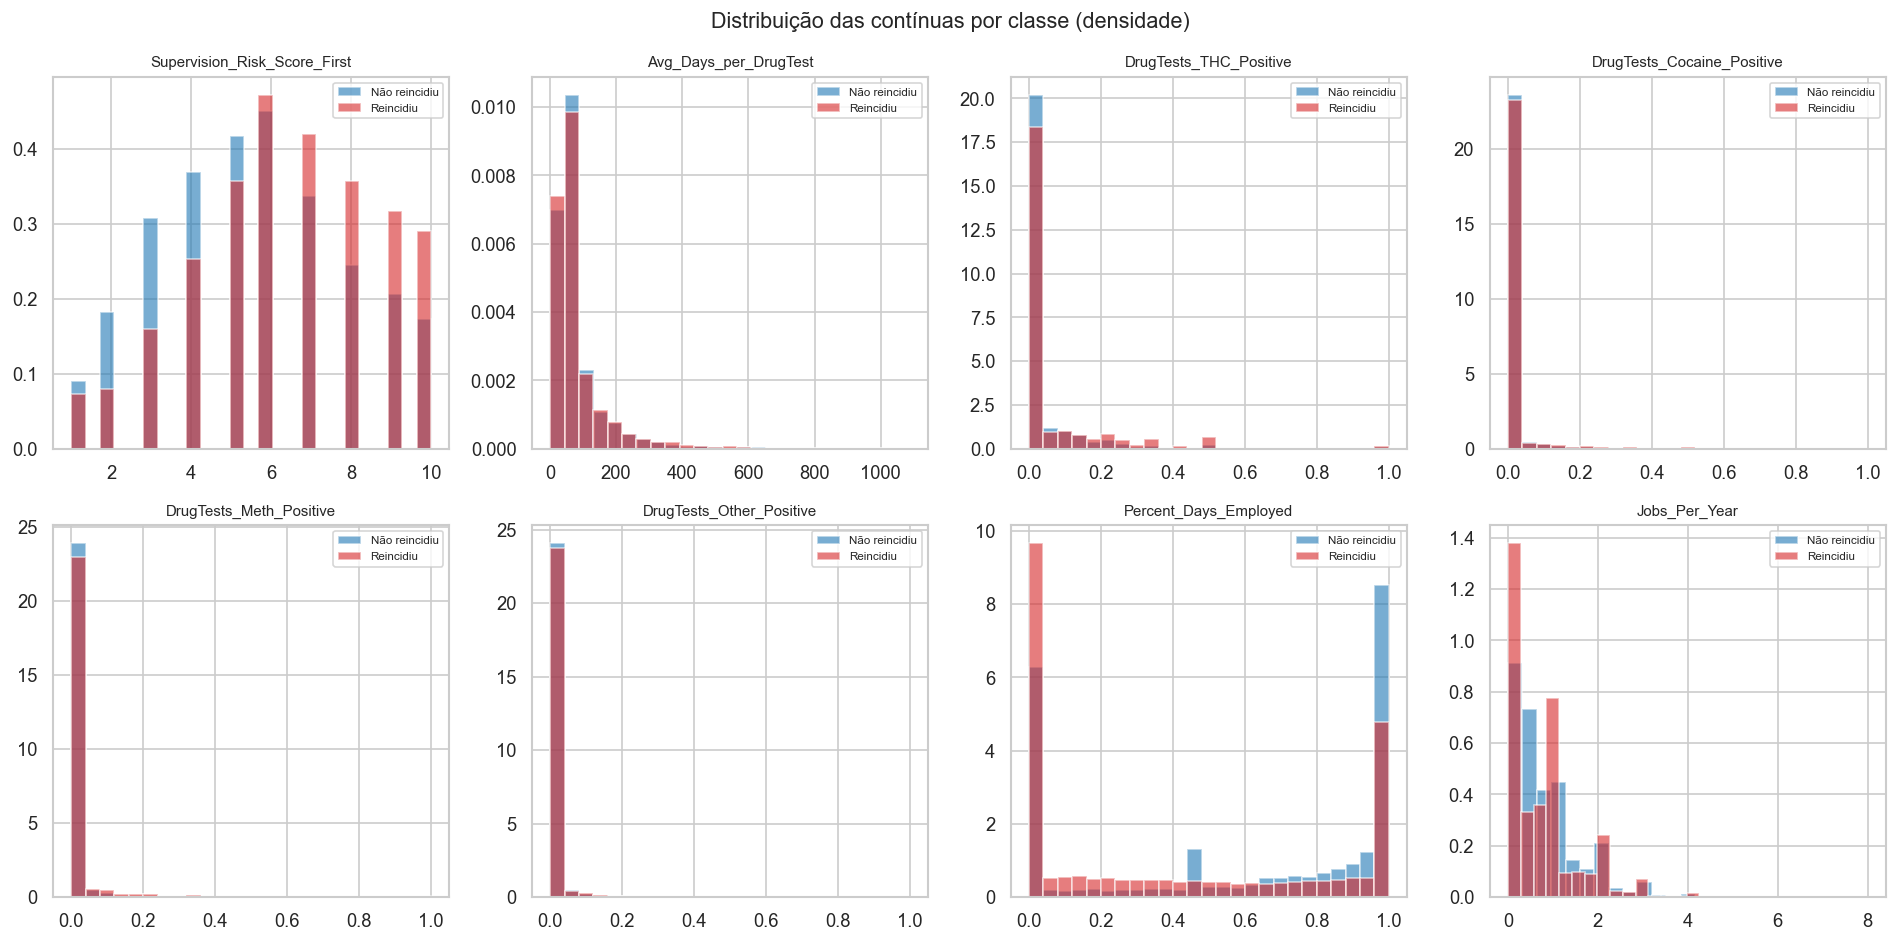

In [9]:

print("=== ANÁLISE BIVARIADA: CONTÍNUAS vs. LABEL ===")
print(df.groupby(LABEL)[CONTINUAS].median().T.rename(
    columns={0: 'Mediana — Não reincidiu', 1: 'Mediana — Reincidiu'}).round(3))

n_cols = 4
n_rows = int(np.ceil(len(CONTINUAS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flat

for ax, col in zip(axes, CONTINUAS):
    data0 = df[df[LABEL] == 0][col].dropna()
    data1 = df[df[LABEL] == 1][col].dropna()
    ax.hist(data0, bins=25, alpha=0.6, color='#1f77b4',
            density=True, label='Não reincidiu')
    ax.hist(data1, bins=25, alpha=0.6, color='#d62728',
            density=True, label='Reincidiu')
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

for ax in list(axes)[len(CONTINUAS):]:
    ax.set_visible(False)

plt.suptitle('Distribuição das contínuas por classe (densidade)',
             fontsize=13)
plt.tight_layout()
plt.show()



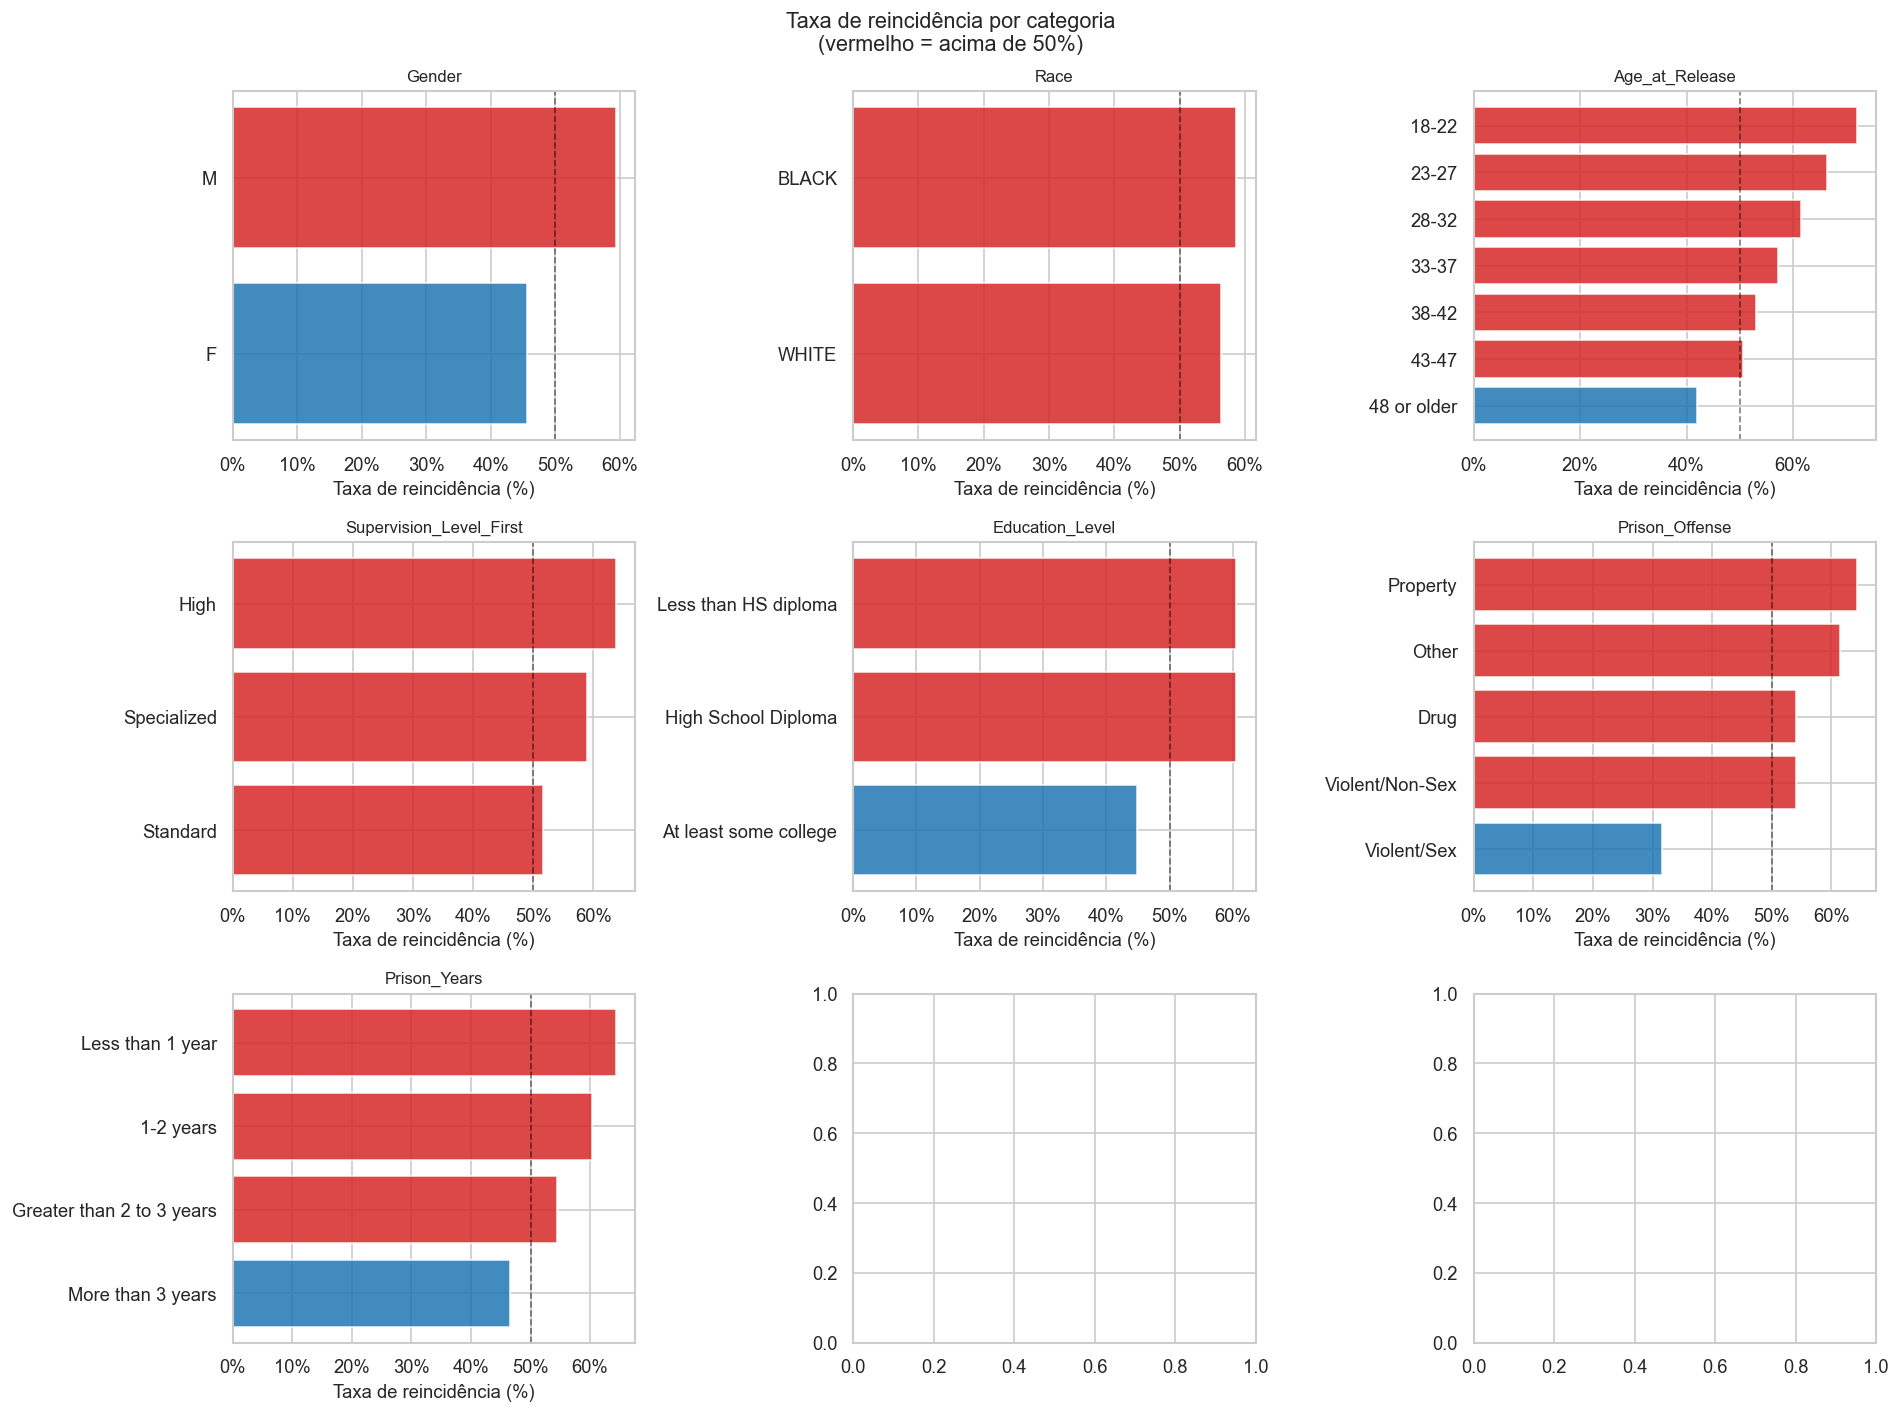

In [21]:
# Análise bivariada: nominais e binárias vs. label
# Taxa de reincidência por categoria — variáveis nominais originais
n_cols = 3
n_rows = int(np.ceil(len(NOMINAIS_ORIG) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flat

for ax, col in zip(axes, NOMINAIS_ORIG):
    taxa = (df_viz.groupby(col)[LABEL]
            .apply(lambda s: (s == 'Reincidiu').mean() * 100)
            .sort_values(ascending=True))
    cores = ['#d62728' if v >= 50 else '#1f77b4' for v in taxa.values]
    ax.barh(taxa.index.astype(str), taxa.values, color=cores,
            edgecolor='white', alpha=0.85)
    ax.axvline(50, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Taxa de reincidência (%)')
    ax.set_title(col, fontsize=10)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

for ax in list(axes)[len(NOMINAIS_ORIG):]:
    ax.set_visible(False)

plt.suptitle('Taxa de reincidência por categoria\n(vermelho = acima de 50%)',
             fontsize=13)
plt.tight_layout()
plt.show()



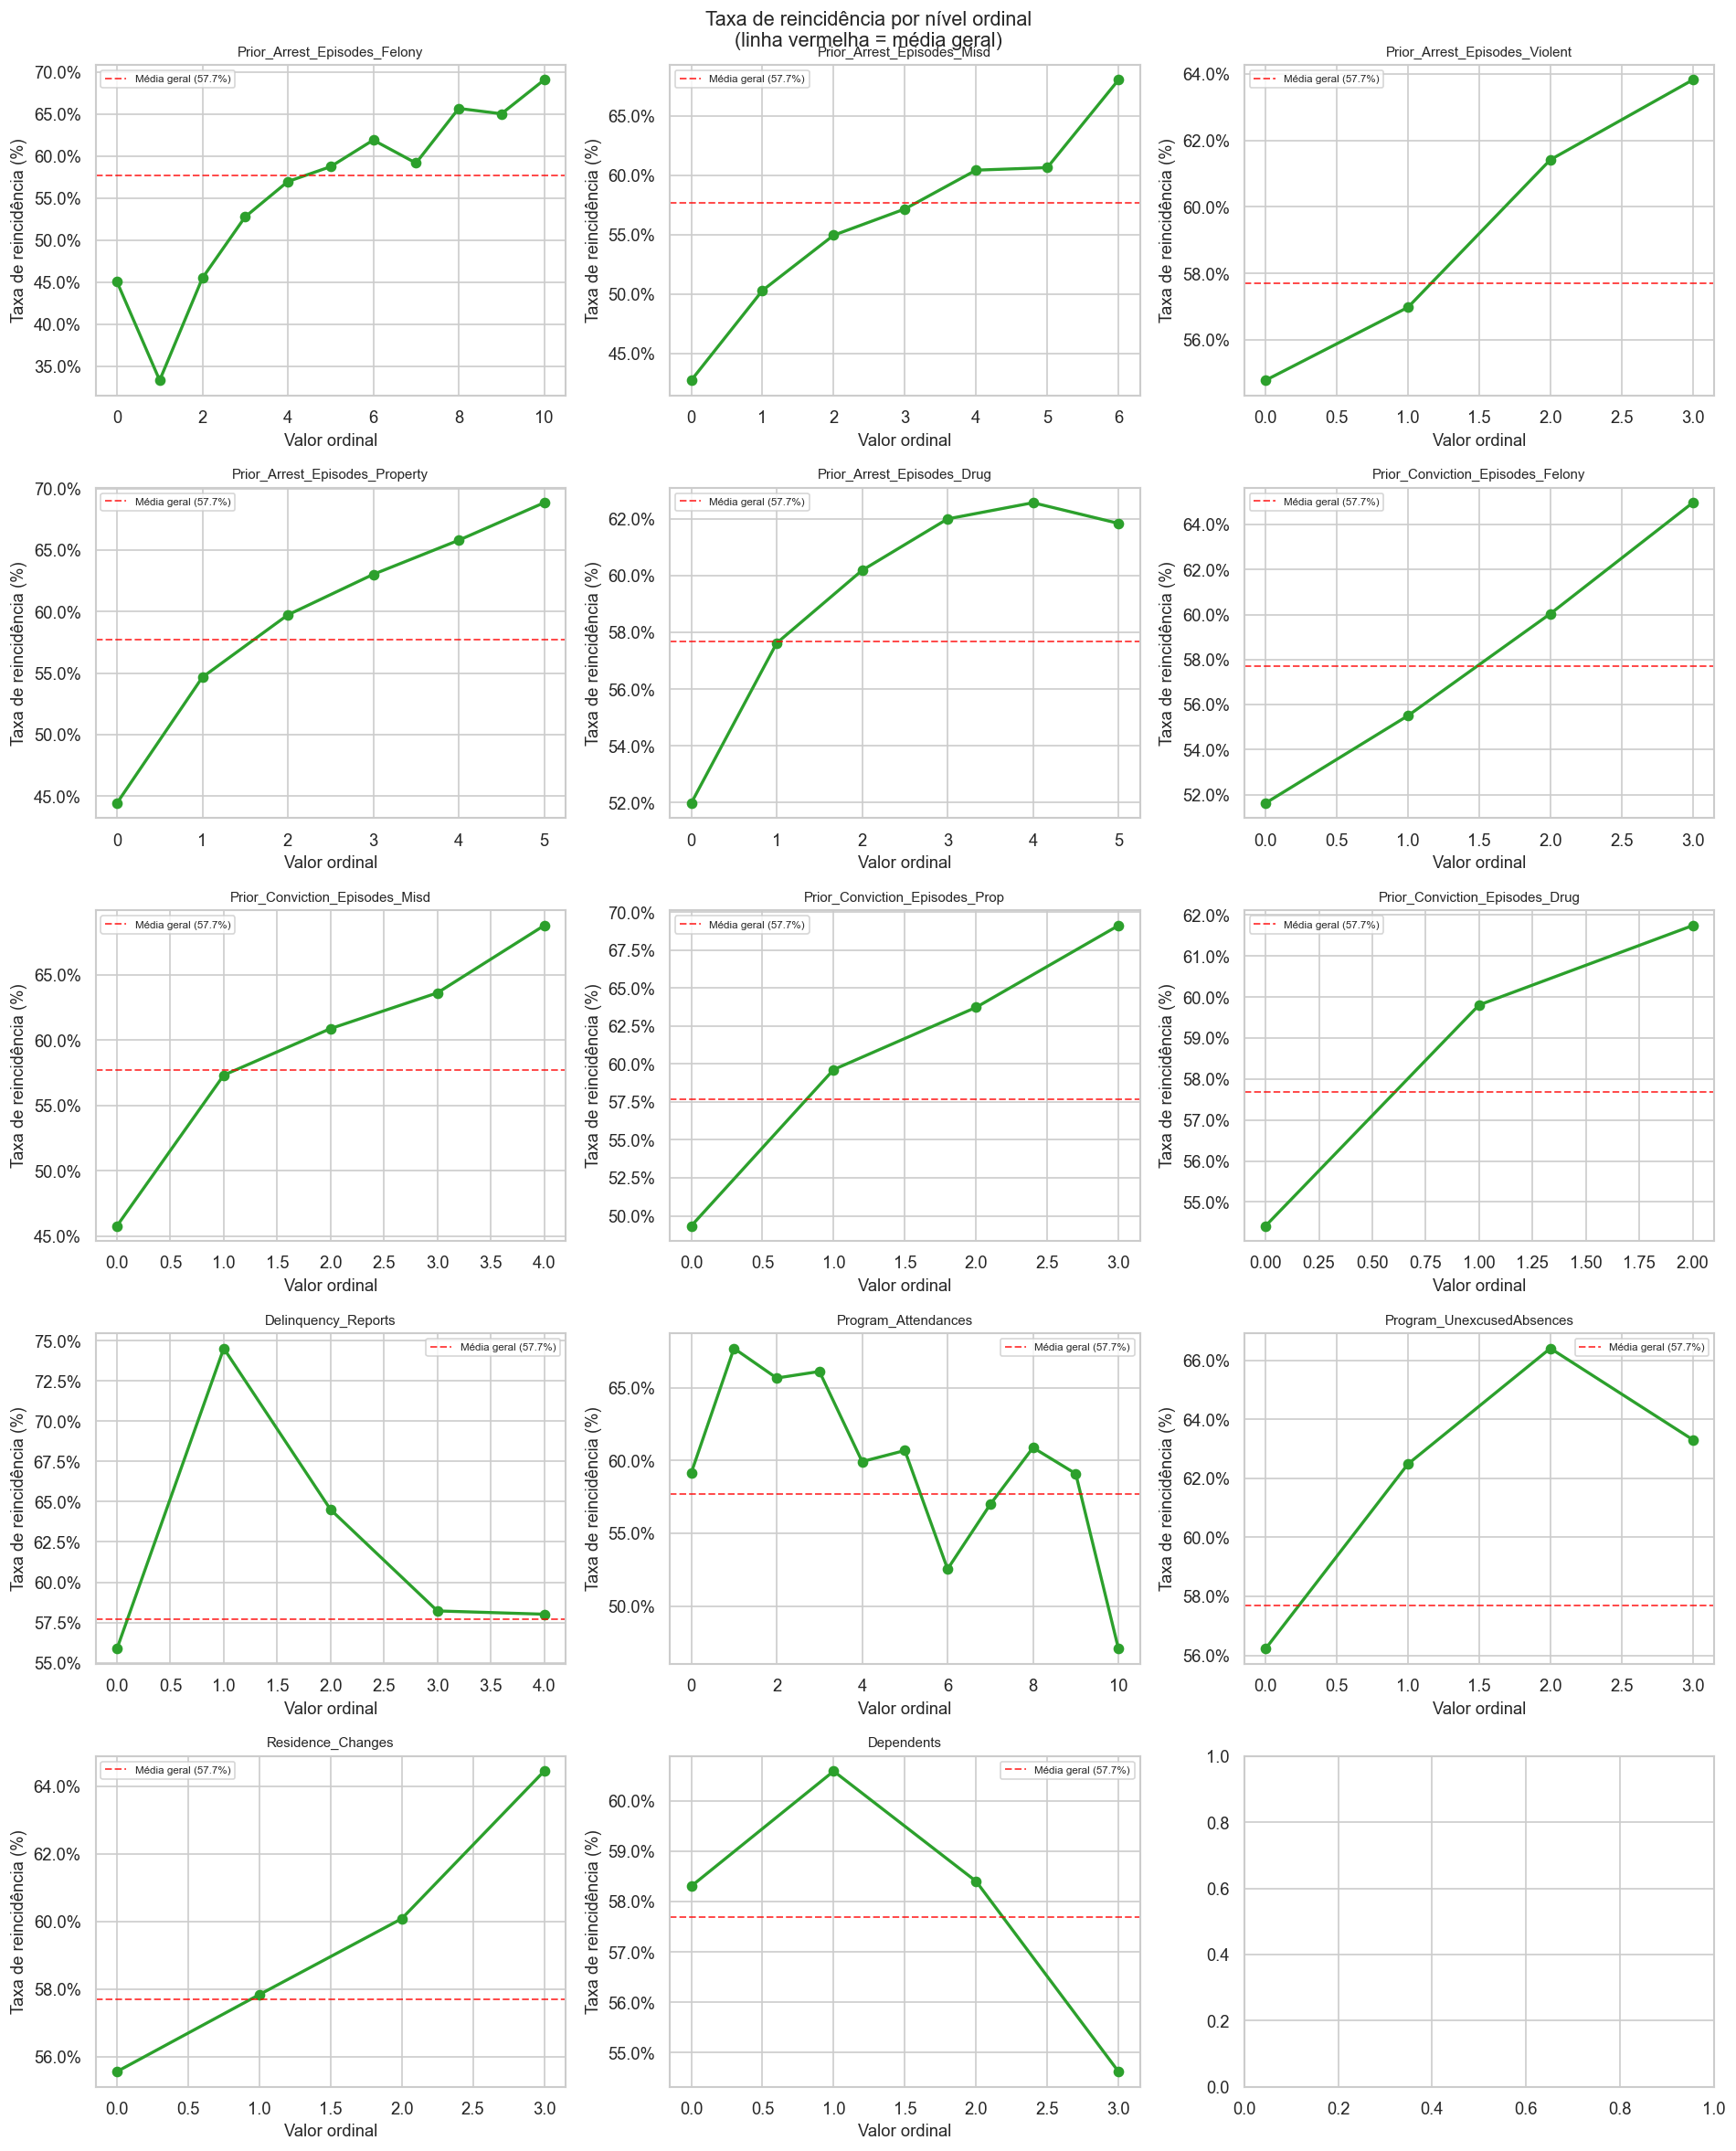

In [11]:
# Análise bivariada: ordinais vs. label (taxa de reincidência)

n_cols = 3
n_rows = int(np.ceil(len(ORDINAIS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flat

for ax, col in zip(axes, ORDINAIS):
    taxa = (df.groupby(col)[LABEL].mean() * 100).sort_index()
    ax.plot(taxa.index, taxa.values, marker='o',
            color='#2ca02c', linewidth=2, markersize=6)
    ax.axhline(df[LABEL].mean() * 100, color='red',
               linestyle='--', linewidth=1.2, alpha=0.7,
               label=f'Média geral ({df[LABEL].mean()*100:.1f}%)')
    ax.set_xlabel('Valor ordinal')
    ax.set_ylabel('Taxa de reincidência (%)')
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

for ax in list(axes)[len(ORDINAIS):]:
    ax.set_visible(False)

plt.suptitle('Taxa de reincidência por nível ordinal\n(linha vermelha = média geral)',
             fontsize=13)
plt.tight_layout()
plt.show()


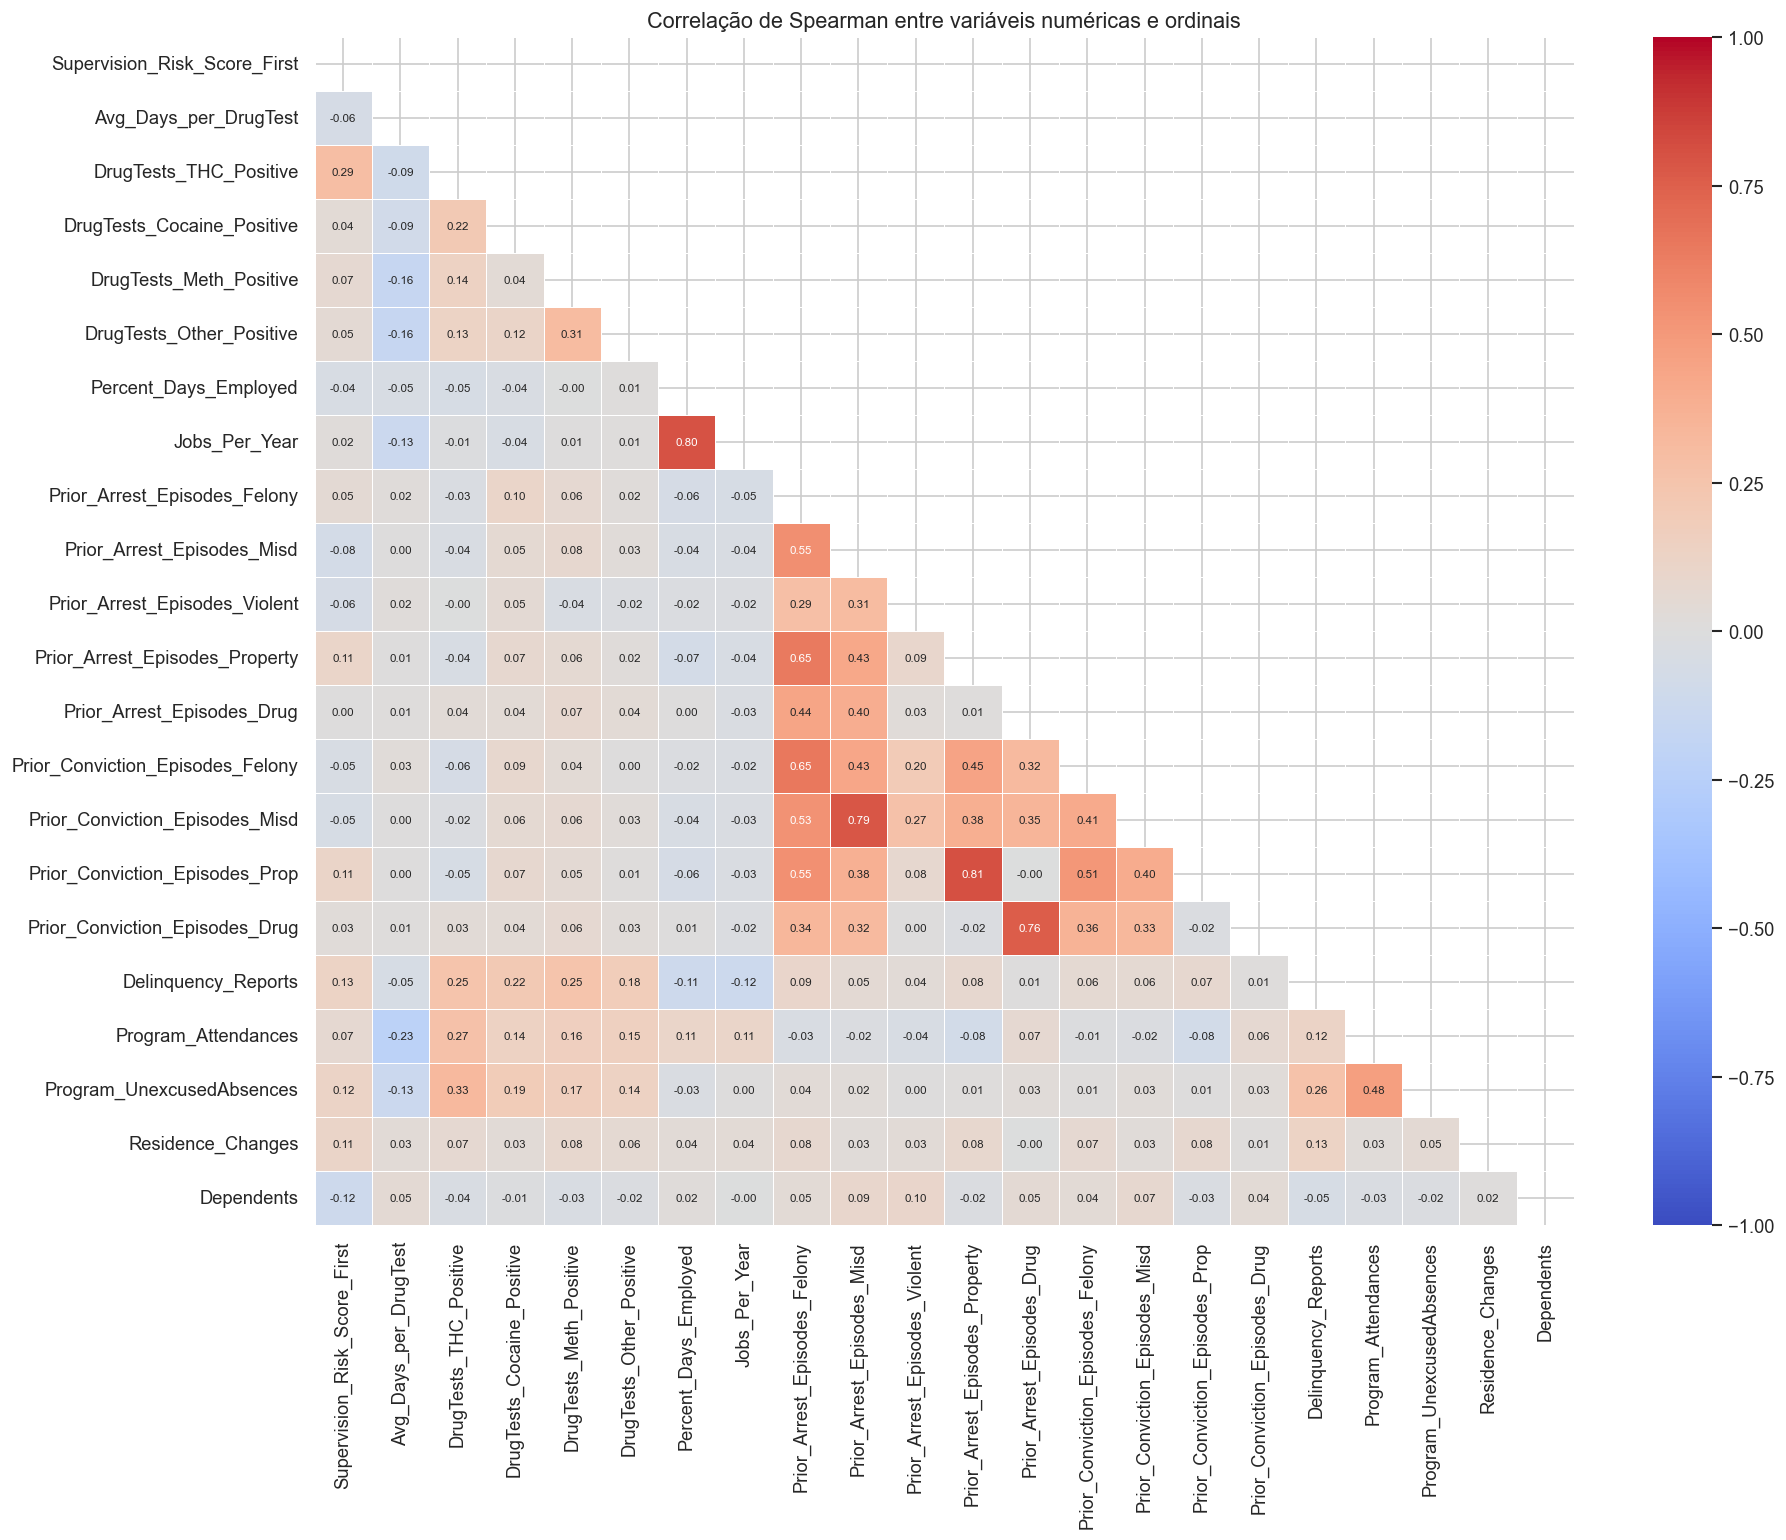

In [12]:
# Correlação entre variáveis numéricas (heatmap)

TODAS_NUMERICAS = CONTINUAS + ORDINAIS
corr = df[TODAS_NUMERICAS].corr(method='spearman')

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))  # mostrar só triângulo inferior
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7},
            linewidths=0.5)
ax.set_title('Correlação de Spearman entre variáveis numéricas e ordinais',
             fontsize=13)
plt.tight_layout()
plt.show()


# Modelagem

In [13]:
FEATURES = [c for c in df.columns if c != LABEL]

X = df[FEATURES]
y = df[LABEL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y)

print(f"Treino : {X_train.shape[0]:,} registros")
print(f"Teste  : {X_test.shape[0]:,} registros")
print(f"\nProporção da label no treino :")
print((y_train.value_counts(normalize=True) * 100).round(1))
print(f"\nProporção da label no teste  :")
print((y_test.value_counts(normalize=True) * 100).round(1))

Treino : 18,084 registros
Teste  : 7,751 registros

Proporção da label no treino :
Recidivism_Within_3years
1    57.7
0    42.3
Name: proportion, dtype: float64

Proporção da label no teste  :
Recidivism_Within_3years
1    57.7
0    42.3
Name: proportion, dtype: float64


In [14]:
def avaliar_modelo(nome, modelo, X_tr, y_tr, X_te, y_te):
    """Imprime métricas e plota matriz de confusão + curva ROC."""

    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    print(f"\n{'='*60}")
    print(f"  {nome}")
    print(f"{'='*60}")
    print(f"  Acurácia (treino) : {accuracy_score(y_tr, modelo.predict(X_tr)):.4f}")
    print(f"  Acurácia (teste)  : {accuracy_score(y_te, y_pred):.4f}")
    print(f"  AUC-ROC           : {roc_auc_score(y_te, y_proba):.4f}")
    print(f"\n  Relatório de classificação:")
    print(classification_report(y_te, y_pred,
          target_names=['Não reincidiu (0)', 'Reincidiu (1)'], digits=4))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Matriz de confusão
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm,
           display_labels=['Não reincidiu', 'Reincidiu'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Matriz de Confusão\n{nome}')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc = roc_auc_score(y_te, y_proba)
    axes[1].plot(fpr, tpr, color='#d62728', linewidth=2,
                 label=f'AUC = {auc:.4f}')
    axes[1].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5,
                 label='Classificador aleatório')
    axes[1].set_xlabel('Taxa de falsos positivos (1 - Especificidade)')
    axes[1].set_ylabel('Taxa de verdadeiros positivos (Sensibilidade)')
    axes[1].set_title(f'Curva ROC\n{nome}')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {'acuracia_treino': accuracy_score(y_tr, modelo.predict(X_tr)),
            'acuracia_teste':  accuracy_score(y_te, y_pred),
            'auc':             auc}


def plot_importancias(modelo, features, titulo, top_n=20):
    """Plota as top_n variáveis mais importantes segundo o modelo."""
    imp = pd.Series(modelo.feature_importances_, index=features)
    imp = imp[imp > 0].sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)))
    imp.sort_values().plot(kind='barh', ax=ax, color='#ff7f0e', edgecolor='white')
    ax.set_xlabel('Importância (redução média do Gini)')
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

    return imp


## Arvore de decisão completa (com todas as variáveis)


  Árvore Completa (todas as variáveis)
  Acurácia (treino) : 1.0000
  Acurácia (teste)  : 0.6465
  AUC-ROC           : 0.6391

  Relatório de classificação:
                   precision    recall  f1-score   support

Não reincidiu (0)     0.5809    0.5909    0.5859      3280
    Reincidiu (1)     0.6960    0.6873    0.6916      4471

         accuracy                         0.6465      7751
        macro avg     0.6385    0.6391    0.6388      7751
     weighted avg     0.6473    0.6465    0.6469      7751



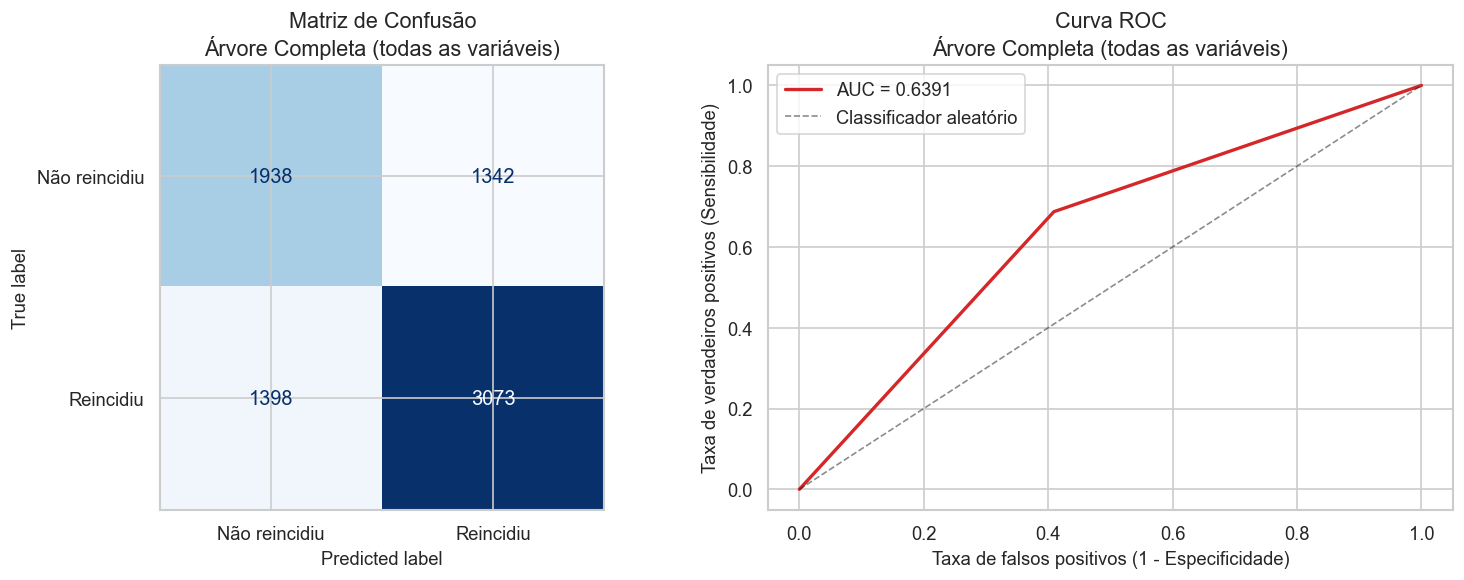


Profundidade da árvore : 30
Número de nós folha    : 3395


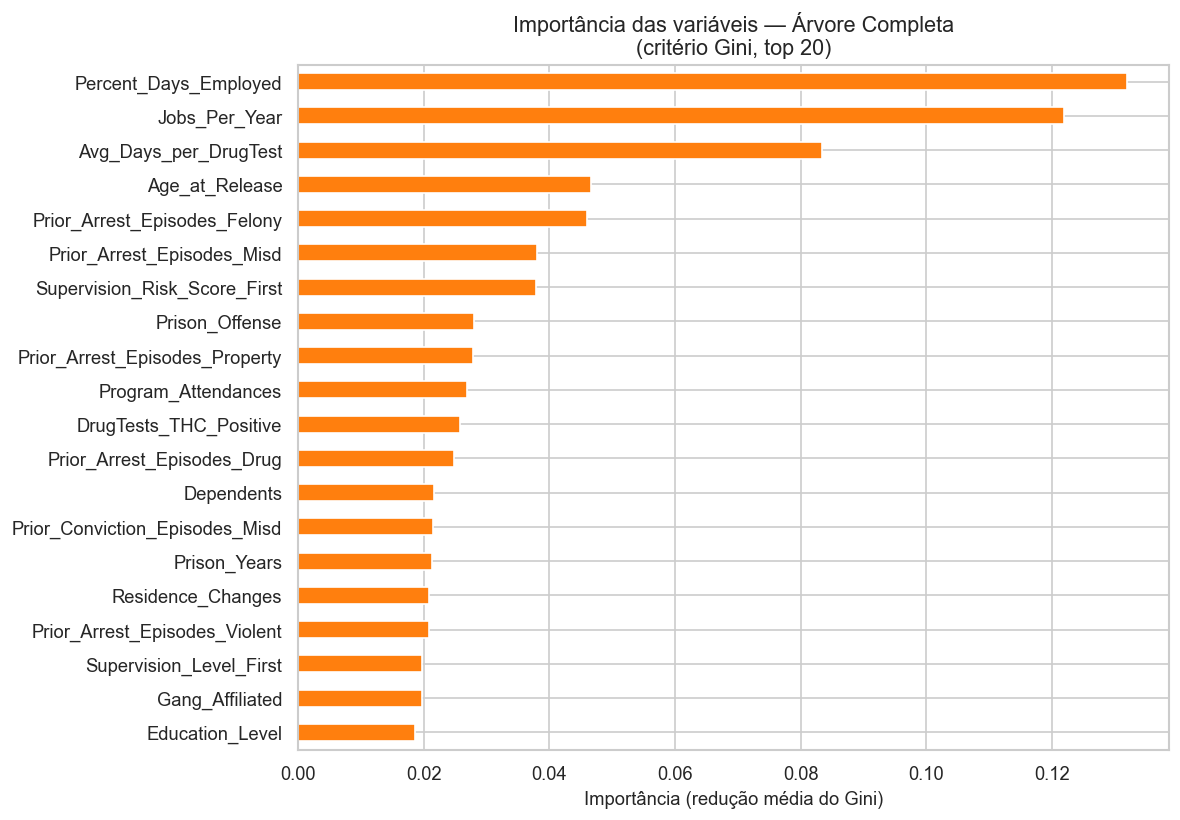


Top 20 variáveis mais importantes (Árvore Completa):
Percent_Days_Employed             0.132025
Jobs_Per_Year                     0.121985
Avg_Days_per_DrugTest             0.083405
Age_at_Release                    0.046693
Prior_Arrest_Episodes_Felony      0.046047
Prior_Arrest_Episodes_Misd        0.038094
Supervision_Risk_Score_First      0.037843
Prison_Offense                    0.027924
Prior_Arrest_Episodes_Property    0.027847
Program_Attendances               0.026919
DrugTests_THC_Positive            0.025722
Prior_Arrest_Episodes_Drug        0.024805
Dependents                        0.021642
Prior_Conviction_Episodes_Misd    0.021397
Prison_Years                      0.021338
Residence_Changes                 0.020880
Prior_Arrest_Episodes_Violent     0.020760
Supervision_Level_First           0.019772
Gang_Affiliated                   0.019644
Education_Level                   0.018534


In [15]:
# Árvore sem restrição de profundidade, modelo completo
dt_completa = DecisionTreeClassifier(
    criterion='gini',
    random_state=SEED
)
dt_completa.fit(X_train, y_train)

metricas_completa = avaliar_modelo(
    'Árvore Completa (todas as variáveis)',
    dt_completa, X_train, y_train, X_test, y_test
)

print(f"\nProfundidade da árvore : {dt_completa.get_depth()}")
print(f"Número de nós folha    : {dt_completa.get_n_leaves()}")

# Importância das variáveis pela árvore completa
imp_completa = plot_importancias(
    dt_completa, FEATURES,
    'Importância das variáveis — Árvore Completa\n(critério Gini, top 20)',
    top_n=20
)

print("\nTop 20 variáveis mais importantes (Árvore Completa):")
print(imp_completa.to_string())

In [16]:

# Selecionar variáveis com importância acima da média
importancia_media = imp_completa.mean()
VARS_SELECIONADAS = imp_completa[imp_completa >= importancia_media].index.tolist()

print(f"Importância média (top 20)     : {importancia_media:.4f}")
print(f"Variáveis selecionadas ({len(VARS_SELECIONADAS)}):")
for v in VARS_SELECIONADAS:
    print(f"  {v:<45}  {imp_completa[v]:.4f}")


Importância média (top 20)     : 0.0402
Variáveis selecionadas (5):
  Percent_Days_Employed                          0.1320
  Jobs_Per_Year                                  0.1220
  Avg_Days_per_DrugTest                          0.0834
  Age_at_Release                                 0.0467
  Prior_Arrest_Episodes_Felony                   0.0460


### Árvore de decisão com variáveis selecionadas


  Árvore com Variáveis Selecionadas (5 vars)
  Acurácia (treino) : 0.9686
  Acurácia (teste)  : 0.6299
  AUC-ROC           : 0.6177

  Relatório de classificação:
                   precision    recall  f1-score   support

Não reincidiu (0)     0.5652    0.5433    0.5540      3280
    Reincidiu (1)     0.6742    0.6934    0.6836      4471

         accuracy                         0.6299      7751
        macro avg     0.6197    0.6183    0.6188      7751
     weighted avg     0.6281    0.6299    0.6288      7751



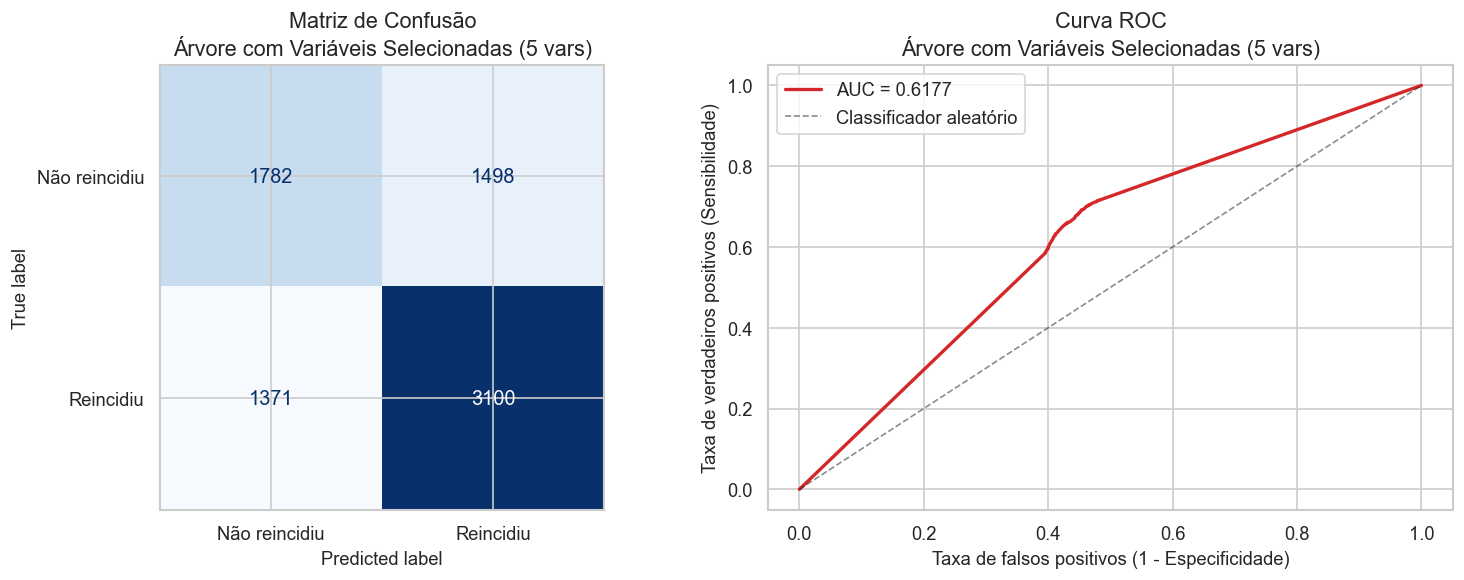


Profundidade da árvore : 43
Número de nós folha    : 4794


In [17]:

X_train_sel = X_train[VARS_SELECIONADAS]
X_test_sel  = X_test[VARS_SELECIONADAS]

dt_selecionada = DecisionTreeClassifier(
    criterion='gini',
    random_state=SEED
)
dt_selecionada.fit(X_train_sel, y_train)

metricas_selecionada = avaliar_modelo(
    f'Árvore com Variáveis Selecionadas ({len(VARS_SELECIONADAS)} vars)',
    dt_selecionada, X_train_sel, y_train, X_test_sel, y_test
)

print(f"\nProfundidade da árvore : {dt_selecionada.get_depth()}")
print(f"Número de nós folha    : {dt_selecionada.get_n_leaves()}")


=== IMPACTO DA PROFUNDIDADE MÁXIMA ===
 max_depth  acuracia_treino  acuracia_teste      auc  n_folhas
         3         0.681099        0.684170 0.702895         8
         4         0.687127        0.681718 0.722932        15
         5         0.702942        0.697071 0.734789        29
         6         0.708140        0.698620 0.744300        56
         7         0.725780        0.704296 0.747902       107
         8         0.733300        0.700297 0.743880       187


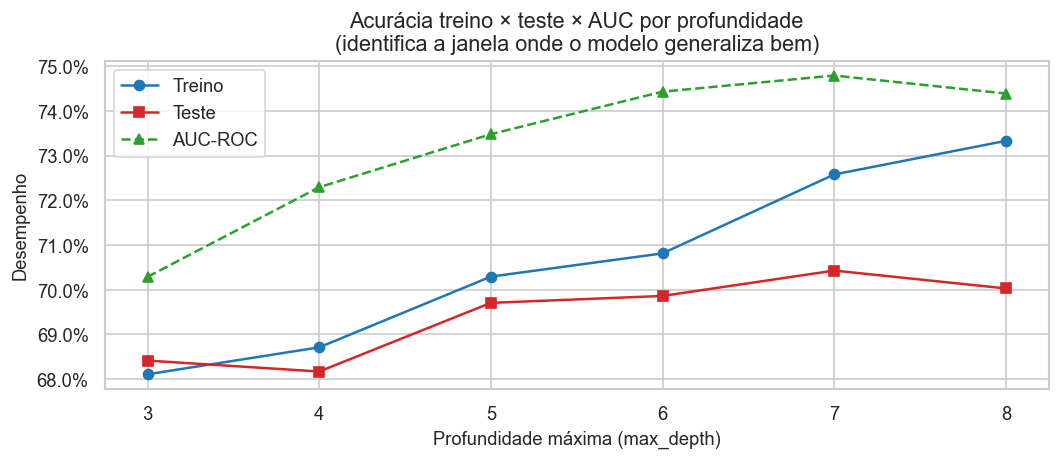

In [18]:
# Árvore PODADA com variáveis selecionadas (para apresentação)
# Árvores sem restrição são profundas demais para visualizar e tendem a
# overfitar. Aqui treinamos versões com profundidade limitada para
# interpretação e apresentação.

resultados_poda = []

for profundidade in [3, 4, 5, 6, 7, 8]:
    dt_pod = DecisionTreeClassifier(
        criterion='gini',
        max_depth=profundidade,
        random_state=SEED
    )
    dt_pod.fit(X_train_sel, y_train)
    y_pred  = dt_pod.predict(X_test_sel)
    y_proba = dt_pod.predict_proba(X_test_sel)[:, 1]
    resultados_poda.append({
        'max_depth':        profundidade,
        'acuracia_treino':  accuracy_score(y_train, dt_pod.predict(X_train_sel)),
        'acuracia_teste':   accuracy_score(y_test,  y_pred),
        'auc':              roc_auc_score(y_test,   y_proba),
        'n_folhas':         dt_pod.get_n_leaves(),
    })

df_poda = pd.DataFrame(resultados_poda)
print("=== IMPACTO DA PROFUNDIDADE MÁXIMA ===")
print(df_poda.to_string(index=False))

# Gráfico acurácia treino vs teste por profundidade
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_poda['max_depth'], df_poda['acuracia_treino'],
        marker='o', label='Treino', color='#1f77b4')
ax.plot(df_poda['max_depth'], df_poda['acuracia_teste'],
        marker='s', label='Teste',  color='#d62728')
ax.plot(df_poda['max_depth'], df_poda['auc'],
        marker='^', label='AUC-ROC', color='#2ca02c', linestyle='--')
ax.set_xlabel('Profundidade máxima (max_depth)')
ax.set_ylabel('Desempenho')
ax.set_title('Acurácia treino × teste × AUC por profundidade\n'
             '(identifica a janela onde o modelo generaliza bem)')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()


Melhor profundidade (maior AUC no teste): 7

  Árvore Podada (max_depth=7, 5 vars)
  Acurácia (treino) : 0.7258
  Acurácia (teste)  : 0.7043
  AUC-ROC           : 0.7479

  Relatório de classificação:
                   precision    recall  f1-score   support

Não reincidiu (0)     0.6903    0.5463    0.6099      3280
    Reincidiu (1)     0.7113    0.8202    0.7619      4471

         accuracy                         0.7043      7751
        macro avg     0.7008    0.6833    0.6859      7751
     weighted avg     0.7024    0.7043    0.6976      7751



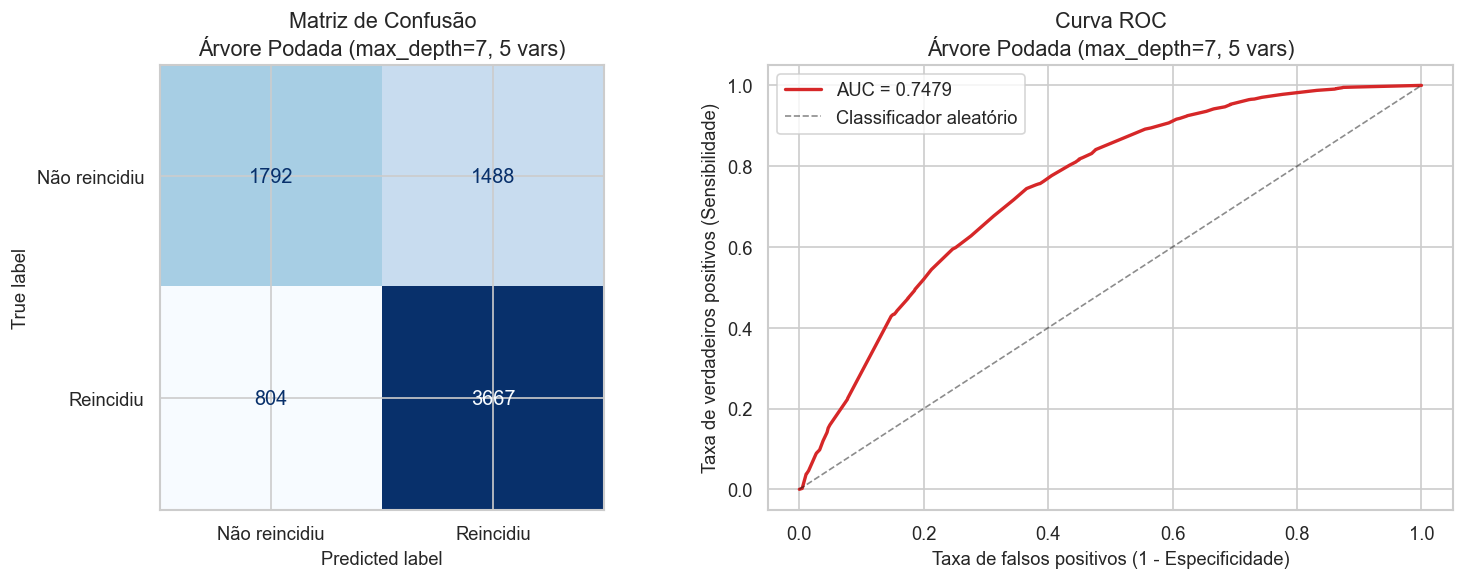

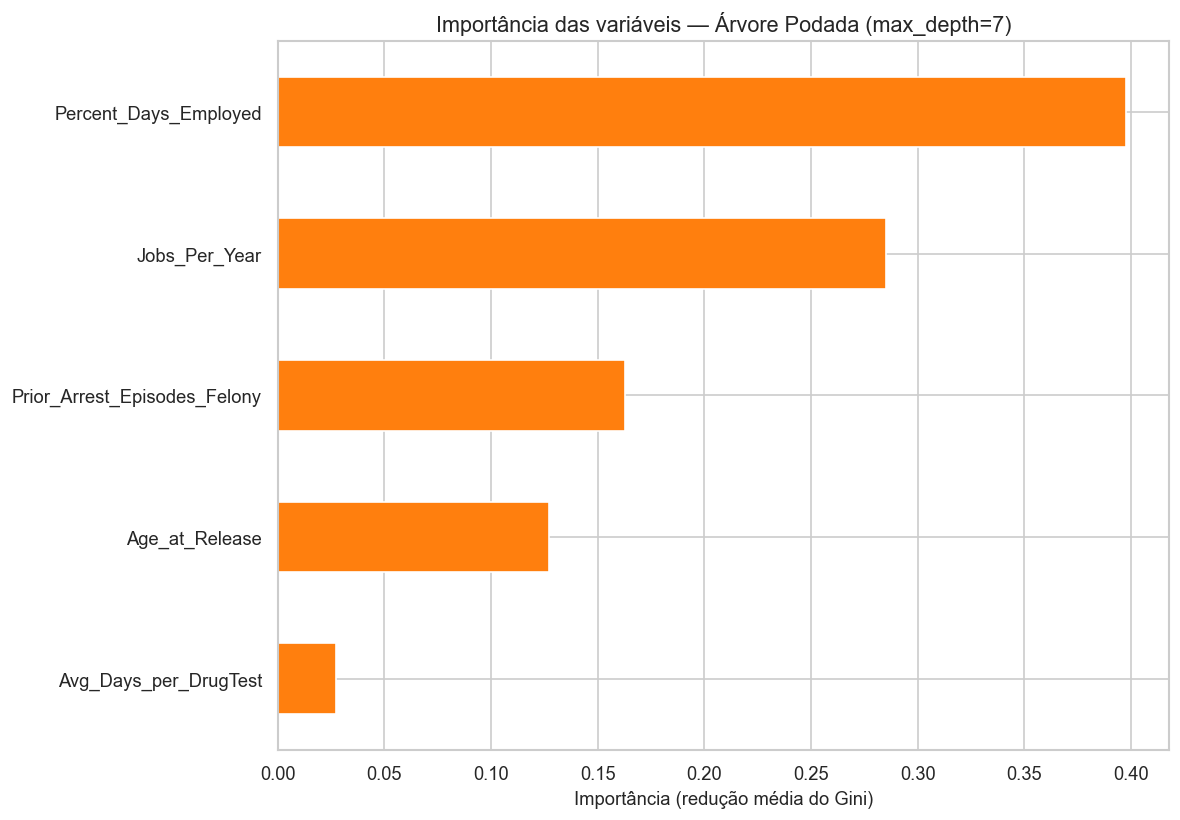

In [19]:
# Escolher a profundidade com maior AUC no teste (critério mais robusto que acurácia)
melhor_depth = df_poda.loc[df_poda['auc'].idxmax(), 'max_depth']
print(f"Melhor profundidade (maior AUC no teste): {melhor_depth}")

dt_podada = DecisionTreeClassifier(
    criterion='gini',
    max_depth=melhor_depth,
    random_state=SEED
)
dt_podada.fit(X_train_sel, y_train)

metricas_podada = avaliar_modelo(
    f'Árvore Podada (max_depth={melhor_depth}, {len(VARS_SELECIONADAS)} vars)',
    dt_podada, X_train_sel, y_train, X_test_sel, y_test
)

# Importância na árvore podada
imp_podada = plot_importancias(
    dt_podada, VARS_SELECIONADAS,
    f'Importância das variáveis — Árvore Podada (max_depth={melhor_depth})'
)

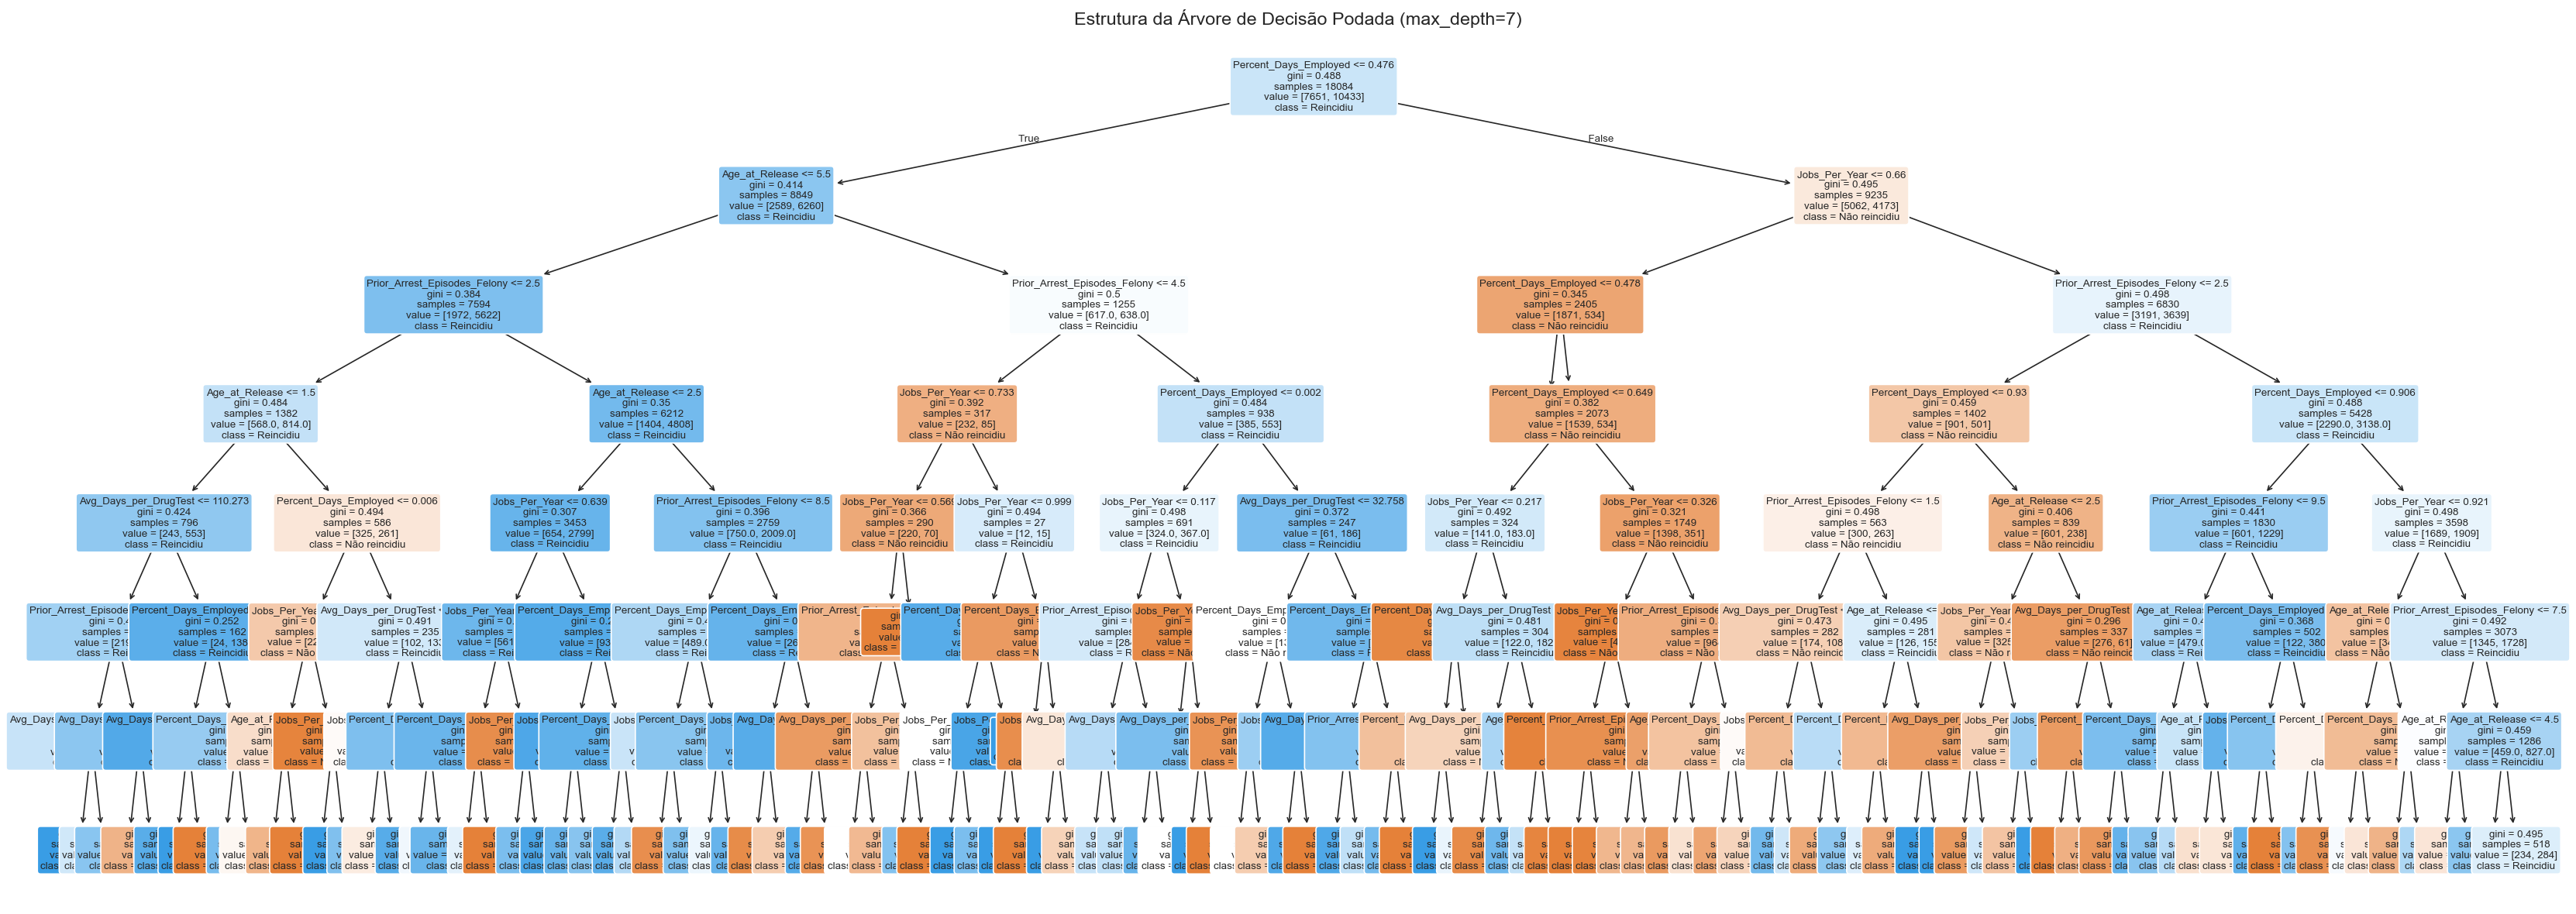


=== ESTRUTURA DA ÁRVORE (texto) ===
|--- Percent_Days_Employed <= 0.48
|   |--- Age_at_Release <= 5.50
|   |   |--- Prior_Arrest_Episodes_Felony <= 2.50
|   |   |   |--- Age_at_Release <= 1.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Age_at_Release >  1.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- Prior_Arrest_Episodes_Felony >  2.50
|   |   |   |--- Age_at_Release <= 2.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Age_at_Release >  2.50
|   |   |   |   |--- truncated branch of depth 4
|   |--- Age_at_Release >  5.50
|   |   |--- Prior_Arrest_Episodes_Felony <= 4.50
|   |   |   |--- Jobs_Per_Year <= 0.73
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Jobs_Per_Year >  0.73
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- Prior_Arrest_Episodes_Felony >  4.50
|   |   |   |--- Percent_Days_Employed <= 0.00
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Percent_Days_Employ

In [20]:

fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(
    dt_podada,
    feature_names=VARS_SELECIONADAS,
    class_names=['Não reincidiu', 'Reincidiu'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False,
)
ax.set_title(f'Estrutura da Árvore de Decisão Podada (max_depth={melhor_depth})',
             fontsize=14)
plt.tight_layout()
plt.show()

# Versão texto da árvore (útil para relatórios)
print("\n=== ESTRUTURA DA ÁRVORE (texto) ===")
print(export_text(dt_podada, feature_names=VARS_SELECIONADAS, max_depth=3))

=== COMPARATIVO FINAL ===
                                       Acurácia Treino  Acurácia Teste  AUC-ROC
Modelo                                                                         
Árvore Completa (todas as vars)                 1.0000          0.6465   0.6391
Árvore Selecionada (5 vars, sem poda)           0.9686          0.6299   0.6177
Árvore Podada (max_depth=7)                     0.7258          0.7043   0.7479


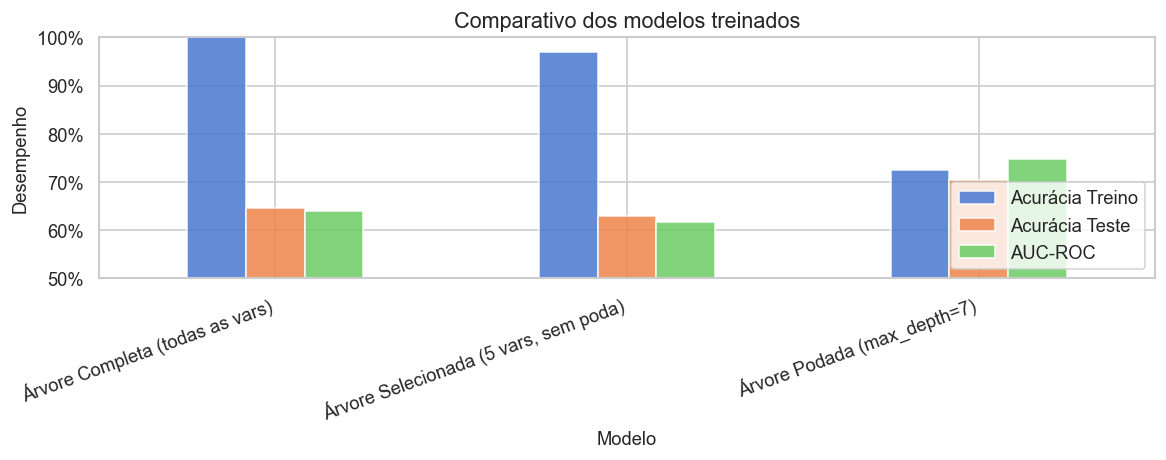

In [24]:

df_comparativo = pd.DataFrame([
    {'Modelo': 'Árvore Completa (todas as vars)',
     **metricas_completa},
    {'Modelo': f'Árvore Selecionada ({len(VARS_SELECIONADAS)} vars, sem poda)',
     **metricas_selecionada},
    {'Modelo': f'Árvore Podada (max_depth={melhor_depth})',
     **metricas_podada},
]).set_index('Modelo')

df_comparativo.columns = ['Acurácia Treino', 'Acurácia Teste', 'AUC-ROC']
print("=== COMPARATIVO FINAL ===")
print(df_comparativo.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
df_comparativo.plot(kind='bar', ax=ax, edgecolor='white', alpha=0.85)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Desempenho')
ax.set_title('Comparativo dos modelos treinados')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(loc='lower right')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [26]:
# =============================================================================
# CÉLULA 22 — Árvore de Decisão INTERATIVA (D3.js, colapsável)
#
# Gera um arquivo HTML autossuficiente com:
#   - Nós colapsáveis: clique em qualquer nó para expandir/colapsar
#   - % de reincidência exibida em destaque em cada nó (sem usar cor para classe)
#   - Cor dos nós indica impureza Gini (azul escuro = puro, azul claro = impuro)
#   - Zoom com scroll, arraste para mover
#   - Botões: expandir tudo, colapsar tudo, resetar zoom
# =============================================================================
 
import json
from IPython.display import IFrame, display
from sklearn.tree import _tree
 
 
def tree_para_json(modelo, feature_names, classe_alvo_nome='Reincidência'):
    """Converte árvore sklearn em dicionário JSON para renderização D3."""
    tree = modelo.tree_
    feature_names = list(feature_names)
 
    def construir_no(nid):
        n       = int(tree.n_node_samples[nid])
        v       = tree.value[nid][0]
        # value pode ser proporção ou contagem — normalizar sempre para proporção × n
        total_v = float(v[0] + v[1])
        n_neg   = int(round(float(v[0]) / total_v * n))
        n_pos   = int(round(float(v[1]) / total_v * n))
        pct     = round(n_pos / n * 100, 1)
        gini    = round(float(tree.impurity[nid]), 4)
        eh_folha = bool(tree.children_left[nid] == _tree.TREE_LEAF)
 
        if eh_folha:
            regra = 'Folha'
            pred  = 'Reincidiu' if n_pos > n_neg else 'Não reincidiu'
        else:
            feat  = feature_names[int(tree.feature[nid])]
            thres = round(float(tree.threshold[nid]), 3)
            regra = f'{feat} \u2264 {thres}'
            pred  = None
 
        no = dict(id=int(nid), regra=str(regra), n=n,
                  n_pos=n_pos, n_neg=n_neg, pct=pct, gini=gini,
                  folha=eh_folha,
                  pred=str(pred) if pred else None,
                  classe_alvo=str(classe_alvo_nome))
 
        if not eh_folha:
            esq  = int(tree.children_left[nid])
            dir_ = int(tree.children_right[nid])
            no['children'] = [construir_no(esq), construir_no(dir_)]
            no['children'][0]['lado'] = 'sim'
            no['children'][1]['lado'] = 'nao'
        return no
 
    return construir_no(0)
 
 
def gerar_arvore_html(modelo, feature_names,
                      titulo='Árvore de Decisão Interativa',
                      classe_alvo_nome='Reincidência',
                      arquivo='arvore_interativa.html'):
    """
    Gera arquivo HTML interativo da árvore com D3.js.
 
    Parâmetros
    ----------
    modelo            : DecisionTreeClassifier treinado
    feature_names     : lista de nomes das features usadas no treino
    titulo            : título exibido no cabeçalho
    classe_alvo_nome  : nome da classe positiva para rótulo do %
    arquivo           : caminho do arquivo HTML de saída
    """
    tree_json_str = json.dumps(
        tree_para_json(modelo, feature_names, classe_alvo_nome),
        ensure_ascii=False
    )
 
    html = f"""<!DOCTYPE html>
<html lang="pt-BR">
<head>
<meta charset="UTF-8">
<title>{titulo}</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/d3/7.8.5/d3.min.js"></script>
<style>
body{{margin:0;font-family:'Segoe UI',Arial,sans-serif;background:#f0f4f8;}}
#header{{background:#1a365d;color:white;padding:14px 20px;font-size:16px;font-weight:bold;}}
#legend{{background:white;padding:8px 20px;font-size:12px;border-bottom:1px solid #ddd;display:flex;gap:20px;align-items:center;flex-wrap:wrap;}}
.leg-item{{display:flex;align-items:center;gap:6px;}}
.leg-box{{width:16px;height:16px;border-radius:3px;border:1px solid #aaa;flex-shrink:0;}}
#controls{{background:white;padding:8px 20px;font-size:12px;border-bottom:1px solid #ddd;display:flex;gap:12px;align-items:center;}}
button{{padding:5px 12px;border:1px solid #aaa;border-radius:4px;cursor:pointer;background:#f7f7f7;font-size:12px;}}
button:hover{{background:#e0e0e0;}}
#svg-container{{width:100%;overflow:auto;background:#f8fafc;}}
svg{{display:block;cursor:grab;}}
svg:active{{cursor:grabbing;}}
.link{{fill:none;stroke:#bbb;stroke-width:2px;}}
.link-label{{font-size:11px;font-style:italic;font-weight:bold;}}
.node rect{{stroke:#555;stroke-width:1.5px;cursor:pointer;}}
.node rect:hover{{stroke:#1a365d;stroke-width:3px;}}
.node text{{pointer-events:none;}}
.node-folha > rect:first-child{{stroke-dasharray:6,3;stroke-width:2px;}}
</style>
</head>
<body>
<div id="header">{titulo}</div>
<div id="legend">
  <b>Cor (impureza Gini):</b>
  <div class="leg-item"><div class="leg-box" style="background:#08306b"></div>Gini&asymp;0 (puro)</div>
  <div class="leg-item"><div class="leg-box" style="background:#4292c6"></div>Gini&asymp;0.25</div>
  <div class="leg-item"><div class="leg-box" style="background:#c6dbef"></div>Gini&asymp;0.5 (m&aacute;x)</div>
  <div class="leg-item"><div class="leg-box" style="background:white;border:2px dashed #555;"></div>N&oacute; folha</div>
  <span style="color:#888;margin-left:8px;">&#128161; Clique em qualquer n&oacute; para colapsar/expandir</span>
</div>
<div id="controls">
  <button onclick="expandAll()">&#9660; Expandir tudo</button>
  <button onclick="collapseAll()">&#9650; Colapsar tudo</button>
  <button onclick="resetZoom()">&#8635; Resetar zoom</button>
  <span style="color:#888;font-size:11px;">Scroll = zoom &nbsp;|&nbsp; Arrastar = mover</span>
</div>
<div id="svg-container"></div>
<script>
const DATA = {tree_json_str};
const NODE_W=210, NODE_H=95, H_GAP=28, V_GAP=55;
 
function giniCor(g){{
  const t=Math.min(g/0.5,1);
  return `rgb(${{Math.round(8+(198-8)*t)}},${{Math.round(48+(219-48)*t)}},${{Math.round(107+(239-107)*t)}})`;
}}
function darken(g){{
  const t=Math.min(g/0.5,1);
  return `rgb(${{Math.max(0,Math.round(8+(198-8)*t)-30)}},${{Math.max(0,Math.round(48+(219-48)*t)-30)}},${{Math.max(0,Math.round(107+(239-107)*t)-30)}})`;
}}
function textCor(g){{ return g<0.32?'white':'#111'; }}
 
const collapsed=new Set();
 
function cloneTree(d){{
  const n={{...d}};
  if(d.children&&!collapsed.has(d.id)){{
    n.children=d.children.map(cloneTree);
  }}else{{
    n._kids=d.children||d._kids||null;
    n.children=null;
  }}
  return n;
}}
 
const svg=d3.select('#svg-container').append('svg');
const g=svg.append('g');
const zoom=d3.zoom().scaleExtent([0.08,3]).on('zoom',e=>g.attr('transform',e.transform));
svg.call(zoom);
function resetZoom(){{svg.transition().duration(400).call(zoom.transform,d3.zoomIdentity.translate(60,40));}}
 
function render(){{
  g.selectAll('*').remove();
  const root=d3.hierarchy(cloneTree(DATA),d=>d.children);
  d3.tree().nodeSize([NODE_W+H_GAP, NODE_H+V_GAP])(root);
 
  const descs=root.descendants();
  const xs=descs.map(d=>d.x), ys=descs.map(d=>d.y);
  const minX=Math.min(...xs)-NODE_W/2-30, maxX=Math.max(...xs)+NODE_W/2+30;
  const minY=Math.min(...ys)-30, maxY=Math.max(...ys)+NODE_H+30;
  svg.attr('width',maxX-minX+20).attr('height',maxY-minY+20);
  const ox=-minX+10, oy=-minY+10;
 
  g.selectAll('.link').data(root.links()).join('path').attr('class','link')
    .attr('d',d=>{{
      const sx=d.source.x+ox, sy=d.source.y+NODE_H+oy;
      const tx=d.target.x+ox, ty=d.target.y+oy;
      const my=(sy+ty)/2;
      return `M${{sx}},${{sy}} C${{sx}},${{my}} ${{tx}},${{my}} ${{tx}},${{ty}}`;
    }});
 
  g.selectAll('.link-label').data(root.links()).join('text').attr('class','link-label')
    .attr('x',d=>(d.source.x+d.target.x)/2+ox+(d.target.data.lado==='sim'?-18:18))
    .attr('y',d=>(d.source.y+NODE_H+d.target.y)/2+oy)
    .attr('text-anchor','middle')
    .attr('fill',d=>d.target.data.lado==='sim'?'#276749':'#c53030')
    .text(d=>d.target.data.lado==='sim'?'Sim':'Não');
 
  const nodes=g.selectAll('.node').data(descs).join('g')
    .attr('class',d=>'node'+(d.data.folha?' node-folha':''))
    .attr('transform',d=>`translate(${{d.x+ox-NODE_W/2}},${{d.y+oy}})`);
 
  nodes.append('rect')
    .attr('width',NODE_W).attr('height',NODE_H).attr('rx',8).attr('ry',8)
    .attr('fill',d=>giniCor(d.data.gini))
    .on('click',(ev,d)=>{{
      if(d.data.folha)return;
      collapsed.has(d.data.id)?collapsed.delete(d.data.id):collapsed.add(d.data.id);
      render();
    }});
 
  nodes.filter(d=>!d.data.folha).append('rect')
    .attr('width',NODE_W).attr('height',26).attr('rx',8).attr('ry',8)
    .attr('fill',d=>darken(d.data.gini)).style('pointer-events','none');
 
  nodes.append('line')
    .attr('x1',0).attr('x2',NODE_W).attr('y1',26).attr('y2',26)
    .attr('stroke','rgba(255,255,255,0.25)').attr('stroke-width',1)
    .style('pointer-events','none');
 
  nodes.append('text')
    .attr('x',NODE_W/2).attr('y',17).attr('text-anchor','middle')
    .attr('font-size',11).attr('font-weight','bold')
    .attr('fill',d=>textCor(d.data.gini)).style('pointer-events','none')
    .text(d=>d.data.regra.length>30?d.data.regra.slice(0,29)+'\u2026':d.data.regra)
    .append('title').text(d=>d.data.regra);
 
  nodes.append('text')
    .attr('x',NODE_W/2).attr('y',48).attr('text-anchor','middle')
    .attr('font-size',14).attr('font-weight','bold')
    .attr('fill',d=>textCor(d.data.gini)).style('pointer-events','none')
    .text(d=>`% Reincid\u00eancia: ${{d.data.pct}}%`);
 
  nodes.append('text')
    .attr('x',NODE_W/2).attr('y',65).attr('text-anchor','middle')
    .attr('font-size',10).attr('fill',d=>textCor(d.data.gini)).style('pointer-events','none')
    .text(d=>`n = ${{d.data.n.toLocaleString('pt-BR')}}   Gini = ${{d.data.gini}}`);
 
  nodes.filter(d=>d.data.folha).append('text')
    .attr('x',NODE_W/2).attr('y',82).attr('text-anchor','middle')
    .attr('font-size',11).attr('font-weight','bold')
    .attr('fill',d=>textCor(d.data.gini)).style('pointer-events','none')
    .text(d=>'\u2192 '+d.data.pred);
 
  nodes.filter(d=>!d.data.folha).append('text')
    .attr('x',NODE_W/2).attr('y',82).attr('text-anchor','middle')
    .attr('font-size',10).attr('fill',d=>textCor(d.data.gini)).style('pointer-events','none')
    .text(d=>collapsed.has(d.data.id)?'\u25bc expandir (clique)':'\u25b2 colapsar (clique)');
}}
 
function expandAll(){{collapsed.clear();render();}}
function collapseAll(){{
  function col(d){{if(d.children){{collapsed.add(d.id);d.children.forEach(col);}}}}
  if(DATA.children)DATA.children.forEach(col);
  render();
}}
render();
resetZoom();
</script>
</body>
</html>"""
 
    with open(arquivo, 'w', encoding='utf-8') as f:
        f.write(html)
    print(f"Árvore salva em '{arquivo}' — abra no navegador ou use o IFrame abaixo.")
    display(IFrame(src=arquivo, width='100%', height=720))
 
 
# --- Árvore podada interativa ---
gerar_arvore_html(
    modelo           = dt_podada,
    feature_names    = VARS_SELECIONADAS,
    titulo           = f'Árvore Podada — Variáveis Selecionadas (max_depth={melhor_depth})',
    classe_alvo_nome = 'Reincidência',
    arquivo          = 'arvore_podada_interativa.html',
)
 
 
# =============================================================================
# CÉLULA 23 — Árvore COMPLETA interativa (primeiros níveis)
# =============================================================================
 
dt_completa_viz = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=SEED
)
dt_completa_viz.fit(X_train, y_train)
 
gerar_arvore_html(
    modelo           = dt_completa_viz,
    feature_names    = FEATURES,
    titulo           = 'Árvore Completa — Todas as Variáveis (max_depth=5 para visualização)',
    classe_alvo_nome = 'Reincidência',
    arquivo          = 'arvore_completa_interativa.html',
)

Árvore salva em 'arvore_podada_interativa.html' — abra no navegador ou use o IFrame abaixo.


Árvore salva em 'arvore_completa_interativa.html' — abra no navegador ou use o IFrame abaixo.
